# 08 - EDA & Feature Selection

Mục tiêu chính:
1. Hiểu phân bố target `PRCP_label`.
2. Phân tích mùa vụ mưa theo tháng.
3. Phân tích khác biệt mưa theo trạm và theo tháng.
4. Xem phân phối feature theo nhóm mưa / không mưa.
5. Đánh giá mối liên hệ giữa feature và target bằng Correlation, Mann-Whitney U và Mutual Information.
6. Kiểm tra đa cộng tuyến bằng heatmap tương quan toàn bộ biến.
7. Tạo bảng khuyến nghị chọn lọc đặc trưng từ A-Z.

## 1. Import thư viện và cấu hình cơ bản


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

try:
    import seaborn as sns
    HAS_SEABORN = True
    sns.set_theme(style="whitegrid")
except Exception:
    HAS_SEABORN = False

from scipy.stats import mannwhitneyu
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings("ignore")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "data").exists() or (p / "src").exists() or (p / "reports").exists():
            return p
    return Path.cwd()


def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")


def map_station_name(station):
    station_map = {
        "48825099999": "HA DONG",
        "48845099999": "VINH",
        "48863099999": "QUANG NGAI",
        "48877099999": "NHA TRANG",
        "48914099999": "CA MAU",
    }
    station_str = str(station)
    return station_map.get(station_str, station_str)


def get_feature_columns(df, target_col="rain_target"):
    leakage_cols = {
        "time", "DATE", "STATION", "station_name",
        target_col,
        "PRCP", "PRCP_label", "PRCP_log1p",
        "PRCP_mm", "target_prcp_mm", "target_time",
        "YEAR", "MONTH", "month",
    }

    feature_cols = []
    for col in df.columns:
        if col in leakage_cols:
            continue
        if col.endswith("_source"):
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            if df[col].notna().sum() > 0 and df[col].nunique(dropna=True) > 1:
                feature_cols.append(col)

    return feature_cols


def plot_distribution_by_target(df, feature_cols, target_col="rain_target", n_cols=4, title_prefix=""):
    n = len(feature_cols)
    if n == 0:
        print("Không có feature để vẽ.")
        return

    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.2 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, feature_cols):
        plot_df = df[[col, target_col]].copy()
        plot_df[col] = safe_numeric(plot_df[col])
        plot_df[target_col] = safe_numeric(plot_df[target_col])
        plot_df = plot_df.dropna()

        if plot_df.empty:
            ax.set_visible(False)
            continue

        if HAS_SEABORN:
            sns.kdeplot(
                data=plot_df,
                x=col,
                hue=target_col,
                common_norm=False,
                fill=True,
                alpha=0.25,
                ax=ax,
                warn_singular=False,
            )
        else:
            for label in sorted(plot_df[target_col].unique()):
                values = plot_df.loc[plot_df[target_col] == label, col]
                ax.hist(values, bins=30, alpha=0.45, density=True, label=f"{target_col}={label}")
            ax.legend()

        ax.set_title(col)
        ax.set_xlabel("")
        ax.set_ylabel("Density")

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(title_prefix, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


def feature_group(feature):
    f = feature.lower()

    if feature in {"day_sin", "day_cos", "month_sin", "month_cos"}:
        return "seasonality"

    if feature in {"DEWP", "q_850", "q_500", "dew_point_depression"} or "humidity" in f:
        return "moisture"

    if feature in {"SLP", "STP", "sp", "msl"} or "pressure" in f:
        return "pressure"

    if (
        feature.startswith(("u_", "v_", "w_"))
        or "wind" in f
        or "shear" in f
        or "ageostrophic" in f
        or feature in {"u10", "v10", "WDSP"}
    ):
        return "wind_dynamic"

    if feature in {"PRCP_mm_lag_1", "PRCP_mm_lag_2"} or "prcp" in f:
        return "precipitation_history"

    if "enso" in f:
        return "climate"

    if feature in {"LATITUDE", "LONGITUDE", "ELEVATION", "z", "lsm", "elevation_diff"}:
        return "geography"

    if "lapse_rate" in f or "thickness" in f or "temperature" in f or feature in {"TEMP", "t_500", "t_850"}:
        return "thermodynamic"

    if "moisture_flux" in f or "moist_convection" in f:
        return "moisture_dynamic"

    return "other"


def meteorological_meaning(feature):
    group = feature_group(feature)

    meanings = {
        "seasonality": "Biểu diễn chu kỳ mùa vụ, giúp mô hình học tính mùa của mưa.",
        "moisture": "Liên quan đến độ ẩm/điểm sương, là điều kiện nền quan trọng để hình thành mưa.",
        "pressure": "Phản ánh trạng thái áp suất khí quyển, liên quan đến hệ thống áp thấp/áp cao.",
        "wind_dynamic": "Mô tả gió, wind shear hoặc thay đổi động lực khí quyển.",
        "precipitation_history": "Lượng mưa quá khứ, có thể phản ánh tính liên tục của thời tiết ẩm.",
        "climate": "Tín hiệu khí hậu quy mô lớn ENSO và ảnh hưởng trễ.",
        "geography": "Biểu diễn khác biệt không gian/địa hình giữa các trạm.",
        "thermodynamic": "Liên quan đến nhiệt động lực học, bất ổn khí quyển hoặc cấu trúc tầng khí quyển.",
        "moisture_dynamic": "Kết hợp độ ẩm và động lực khí quyển, rất liên quan đến mưa.",
        "other": "Feature bổ trợ, cần xem xét thêm dựa trên tín hiệu thống kê và ý nghĩa vật lý.",
    }
    return meanings.get(group, meanings["other"])


def choose_redundancy_action(row, metric_lookup):
    f1, f2 = row["feature_1"], row["feature_2"]

    engineered_keywords = [
        "dew_point_depression", "moisture_flux", "moist_convection",
        "lapse_rate", "wind_shear", "ageostrophic", "thickness", "elevation_diff"
    ]

    f1_engineered = any(k in f1 for k in engineered_keywords)
    f2_engineered = any(k in f2 for k in engineered_keywords)

    if f1_engineered and not f2_engineered:
        return pd.Series([f1, f2, "Giữ feature engineered vì dễ giải thích khí tượng hơn."])
    if f2_engineered and not f1_engineered:
        return pd.Series([f2, f1, "Giữ feature engineered vì dễ giải thích khí tượng hơn."])

    pair_text = f"{f1} {f2}"
    if "mean" in pair_text and "sum" in pair_text:
        keep = f1 if "mean" in f1 else f2
        review = f2 if keep == f1 else f1
        return pd.Series([keep, review, "Rolling mean và rolling sum gần trùng thông tin; giữ mean để dễ diễn giải."])

    mi1 = metric_lookup.get(f1, {}).get("mutual_information", 0)
    mi2 = metric_lookup.get(f2, {}).get("mutual_information", 0)

    if mi1 >= mi2:
        return pd.Series([f1, f2, "Giữ feature có Mutual Information cao hơn hoặc tương đương."])
    return pd.Series([f2, f1, "Giữ feature có Mutual Information cao hơn."])


## 2. Load dữ liệu và kiểm tra EDA sơ bộ


In [3]:
BASE_DIR = find_project_root()

# Ưu tiên đúng cấu trúc project. Các fallback giúp notebook vẫn chạy khi đặt cạnh file CSV.
candidate_paths = [
    BASE_DIR / "data" / "feature_engineering" / "feature_engineered_data.csv",
    Path("data") / "feature_engineering" / "feature_engineered_data.csv",
    Path("feature_engineered_data.csv"),
]

# Fallback cuối cho môi trường notebook/sandbox: chọn file feature_engineered_data*.csv mới nhất nếu có.
glob_candidates = sorted(Path.cwd().glob("feature_engineered_data*.csv"))
candidate_paths.extend(glob_candidates)

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy feature_engineered_data.csv. "
        "Hãy chạy Step 7 hoặc đặt file CSV cùng thư mục notebook."
    )

df = pd.read_csv(DATA_PATH)

if "time" in df.columns:
    df["time"] = pd.to_datetime(df["time"], errors="coerce")

if "STATION" in df.columns:
    df["STATION"] = df["STATION"].astype(str)
    df["station_name"] = df["STATION"].map(map_station_name)

# Pipeline two-stage hiện tại dùng PRCP_label. Vẫn hỗ trợ rain_target nếu dùng file cũ.
if "PRCP_label" in df.columns:
    TARGET_COL = "PRCP_label"
elif "rain_target" in df.columns:
    TARGET_COL = "rain_target"
else:
    raise ValueError("Dataset phải có cột PRCP_label hoặc rain_target.")

df[TARGET_COL] = safe_numeric(df[TARGET_COL]).astype(int)

FEATURE_COLS = get_feature_columns(df, TARGET_COL)

eda_overview = pd.DataFrame([{
    "data_path": str(DATA_PATH),
    "n_rows": df.shape[0],
    "n_columns": df.shape[1],
    "n_stations": df["STATION"].nunique() if "STATION" in df.columns else None,
    "start_date": df["time"].min() if "time" in df.columns else None,
    "end_date": df["time"].max() if "time" in df.columns else None,
    "target_col": TARGET_COL,
    "n_numeric_features": len(FEATURE_COLS),
    "missing_rate_max_%": round(df.isna().mean().max() * 100, 3),
}])

display(eda_overview)
display(df.head())


,data_path,n_rows,n_columns,n_stations,start_date,end_date,target_col,n_numeric_features,missing_rate_max_%
0,c:\Users\Laptop\PycharmProjects\DS108\data\fea...,18255,76,5,2015-01-03,2024-12-31,PRCP_label,70,0.0


,STATION,time,LATITUDE,LONGITUDE,ELEVATION,TEMP,PRCP,WDSP,DEWP,STP,...,TEMP_3d_mean,DEWP_3d_mean,SLP_3d_mean,VISIB_3d_mean,moisture_flux_3d_sum,PRCP_past_3d_mean,PRCP_past_3d_sum,PRCP_label,PRCP_log1p,station_name
0,48825099999,2015-01-03,20.9667,105.7667,7.91,17.7222,0.000,2.2636,14.1111,1016.8291,...,17.240733,11.703700,1021.666667,9.173200,0.078001,0.000000,0.000,0,0.000000,HA DONG
1,48825099999,2015-01-04,20.9667,105.7667,7.91,20.0000,0.000,2.8809,17.0556,1010.7669,...,18.074067,14.222233,1018.033333,9.173200,0.130970,0.000000,0.000,0,0.000000,HA DONG
2,48825099999,2015-01-05,20.9667,105.7667,7.91,20.8889,0.000,0.8746,19.0556,1008.8389,...,19.537033,16.740767,1014.400000,8.475833,0.193297,0.000000,0.000,0,0.000000,HA DONG
3,48825099999,2015-01-06,20.9667,105.7667,7.91,21.7778,0.254,1.1318,19.9444,1011.4131,...,20.888900,18.685200,1012.800000,7.671167,0.190855,0.000000,0.000,1,0.226338,HA DONG
4,48825099999,2015-01-07,20.9667,105.7667,7.91,17.7222,1.016,3.6011,12.9444,1018.7861,...,20.129633,17.314800,1015.466667,7.939400,0.167862,0.084667,0.254,1,0.701115,HA DONG


## 2.1. Data Quality Audit

Phần này kiểm tra các rủi ro quan trọng trước EDA: duplicate, missing value, consistency của target two-stage

In [4]:
# ============================================================
# DATA QUALITY AUDIT + WDSP MISSING CHECK
# ============================================================

audit_rows = []

def add_audit_item(item, status, value=None, note=""):
    audit_rows.append({
        "check_item": item,
        "status": status,
        "value": value,
        "note": note,
    })

# 1) Duplicate theo STATION + time
if {"STATION", "time"}.issubset(df.columns):
    n_dup = int(df.duplicated(subset=["STATION", "time"]).sum())
    add_audit_item(
        "Duplicate theo STATION + time",
        "PASS" if n_dup == 0 else "REVIEW",
        n_dup,
        "Mỗi trạm nên có tối đa một dòng cho mỗi ngày."
    )

# 2) Missing summary
missing_summary = (
    df.isna().sum()
    .rename("missing_count")
    .to_frame()
)
missing_summary["missing_rate_%"] = (missing_summary["missing_count"] / len(df) * 100).round(3)
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values(
    "missing_count", ascending=False
)

add_audit_item(
    "Missing value toàn dataset",
    "PASS" if missing_summary.empty else "REVIEW",
    int(missing_summary["missing_count"].sum()) if not missing_summary.empty else 0,
    "Nếu còn missing, cần giải thích hoặc xử lý trong pipeline."
)

# 3) Target consistency: PRCP_label = 1 nếu PRCP > 0.1
if {"PRCP", "PRCP_label"}.issubset(df.columns):
    expected_label = (pd.to_numeric(df["PRCP"], errors="coerce").fillna(0) > 0.1).astype(int)
    mismatch = int((expected_label != df["PRCP_label"].astype(int)).sum())
    add_audit_item(
        "Consistency PRCP_label = PRCP > 0.1",
        "PASS" if mismatch == 0 else "FAIL",
        mismatch,
        "Target classification phải khớp đúng threshold rainfall."
    )

# 4) PRCP_log1p consistency
if {"PRCP", "PRCP_log1p"}.issubset(df.columns):
    prcp = pd.to_numeric(df["PRCP"], errors="coerce").fillna(0).clip(lower=0)
    log_target = pd.to_numeric(df["PRCP_log1p"], errors="coerce")
    max_abs_error = float(np.nanmax(np.abs(np.log1p(prcp) - log_target)))
    add_audit_item(
        "Consistency PRCP_log1p = log1p(PRCP)",
        "PASS" if max_abs_error < 1e-6 else "REVIEW",
        round(max_abs_error, 10),
        "Target regression log-scale phải nhất quán với PRCP."
    )

# 5) PRCP âm
if "PRCP" in df.columns:
    n_negative_prcp = int((pd.to_numeric(df["PRCP"], errors="coerce") < 0).sum())
    add_audit_item(
        "PRCP âm",
        "PASS" if n_negative_prcp == 0 else "FAIL",
        n_negative_prcp,
        "Lượng mưa không được âm."
    )

# 6) WDSP missing + kiểm tra khả năng fill bằng ERA5 u10/v10
if "WDSP" in df.columns:
    wdsp_missing = int(df["WDSP"].isna().sum())
    status = "PASS" if wdsp_missing == 0 else "REVIEW"
    note = "WDSP đã sạch." if wdsp_missing == 0 else "Nên fill ở Step 6 bằng sqrt(u10^2 + v10^2) nếu u10/v10 có sẵn."
    add_audit_item("Missing WDSP", status, wdsp_missing, note)

    if {"u10", "v10"}.issubset(df.columns):
        era5_wind_speed = np.sqrt(
            pd.to_numeric(df["u10"], errors="coerce") ** 2
            + pd.to_numeric(df["v10"], errors="coerce") ** 2
        )
        wdsp_after_recommended_fill = pd.to_numeric(df["WDSP"], errors="coerce").fillna(era5_wind_speed)
        wdsp_after_missing = int(wdsp_after_recommended_fill.isna().sum())

        wdsp_audit = pd.DataFrame([{
            "WDSP_missing_before": wdsp_missing,
            "WDSP_missing_after_recommended_fill": wdsp_after_missing,
            "recommended_formula": "WDSP = WDSP.fillna(sqrt(u10^2 + v10^2))",
            "note": "Cell này chỉ audit. Việc fill thật nên nằm trong _06_to_silver.py để đảm bảo reproducibility."
        }])
    else:
        wdsp_audit = pd.DataFrame([{
            "WDSP_missing_before": wdsp_missing,
            "WDSP_missing_after_recommended_fill": None,
            "recommended_formula": None,
            "note": "Không có u10/v10 để audit công thức fill WDSP."
        }])
else:
    wdsp_audit = pd.DataFrame([{
        "WDSP_missing_before": None,
        "WDSP_missing_after_recommended_fill": None,
        "recommended_formula": None,
        "note": "Không tìm thấy cột WDSP."
    }])

# 7) Temporal split sanity theo model hiện tại
if "time" in df.columns:
    split_counts = pd.DataFrame({
        "split": ["train", "valid", "test"],
        "date_rule": ["time < 2023-01-01", "2023-01-01 <= time < 2024-01-01", "time >= 2024-01-01"],
        "n_rows": [
            int((df["time"] < "2023-01-01").sum()),
            int(((df["time"] >= "2023-01-01") & (df["time"] < "2024-01-01")).sum()),
            int((df["time"] >= "2024-01-01").sum()),
        ],
    })
else:
    split_counts = pd.DataFrame()

audit_df = pd.DataFrame(audit_rows)

display(Markdown("### Data Quality Checklist"))
display(audit_df)

display(Markdown("### Missing values còn lại"))
if missing_summary.empty:
    display(Markdown("Không còn missing value trong dataset."))
else:
    display(missing_summary.head(20))

display(Markdown("### WDSP audit"))
display(wdsp_audit)

if not split_counts.empty:
    display(Markdown("### Temporal split sanity check"))
    display(split_counts)

display(Markdown(
    "**Kết luận data quality:**  \n"
    "- EDA không sửa dữ liệu trực tiếp bằng tay; mọi xử lý nên được đưa về pipeline code để đúng guideline reproducibility.  \n"
    "- Nếu `WDSP` còn thiếu, cách xử lý hợp lý là bổ sung ở `_06_to_silver.py` bằng tốc độ gió ERA5 10m từ `u10`, `v10`.  \n"
    "- `PRCP`, `PRCP_label`, `PRCP_log1p` là target/label và không được đưa vào `X` khi train model."
))


### Data Quality Checklist

,check_item,status,value,note
0,Duplicate theo STATION + time,PASS,0.0,Mỗi trạm nên có tối đa một dòng cho mỗi ngày.
1,Missing value toàn dataset,PASS,0.0,"Nếu còn missing, cần giải thích hoặc xử lý tro..."
2,Consistency PRCP_label = PRCP > 0.1,PASS,0.0,Target classification phải khớp đúng threshold...
3,Consistency PRCP_log1p = log1p(PRCP),PASS,0.0,Target regression log-scale phải nhất quán với...
4,PRCP âm,PASS,0.0,Lượng mưa không được âm.
5,Missing WDSP,PASS,0.0,WDSP đã sạch.


### Missing values còn lại

Không còn missing value trong dataset.

### WDSP audit

,WDSP_missing_before,WDSP_missing_after_recommended_fill,recommended_formula,note
0,0,0,WDSP = WDSP.fillna(sqrt(u10^2 + v10^2)),Cell này chỉ audit. Việc fill thật nên nằm tro...


### Temporal split sanity check

,split,date_rule,n_rows
0,train,time < 2023-01-01,14600
1,valid,2023-01-01 <= time < 2024-01-01,1825
2,test,time >= 2024-01-01,1830


**Kết luận data quality:**  
- EDA không sửa dữ liệu trực tiếp bằng tay; mọi xử lý nên được đưa về pipeline code để đúng guideline reproducibility.  
- Nếu `WDSP` còn thiếu, cách xử lý hợp lý là bổ sung ở `_06_to_silver.py` bằng tốc độ gió ERA5 10m từ `u10`, `v10`.  
- `PRCP`, `PRCP_label`, `PRCP_log1p` là target/label và không được đưa vào `X` khi train model.

## 3. Phân tích target và mất cân bằng lớp


,rain_target,count,percent,label
0,0,11229,61.511915,Không mưa
1,1,7026,38.488085,Có mưa


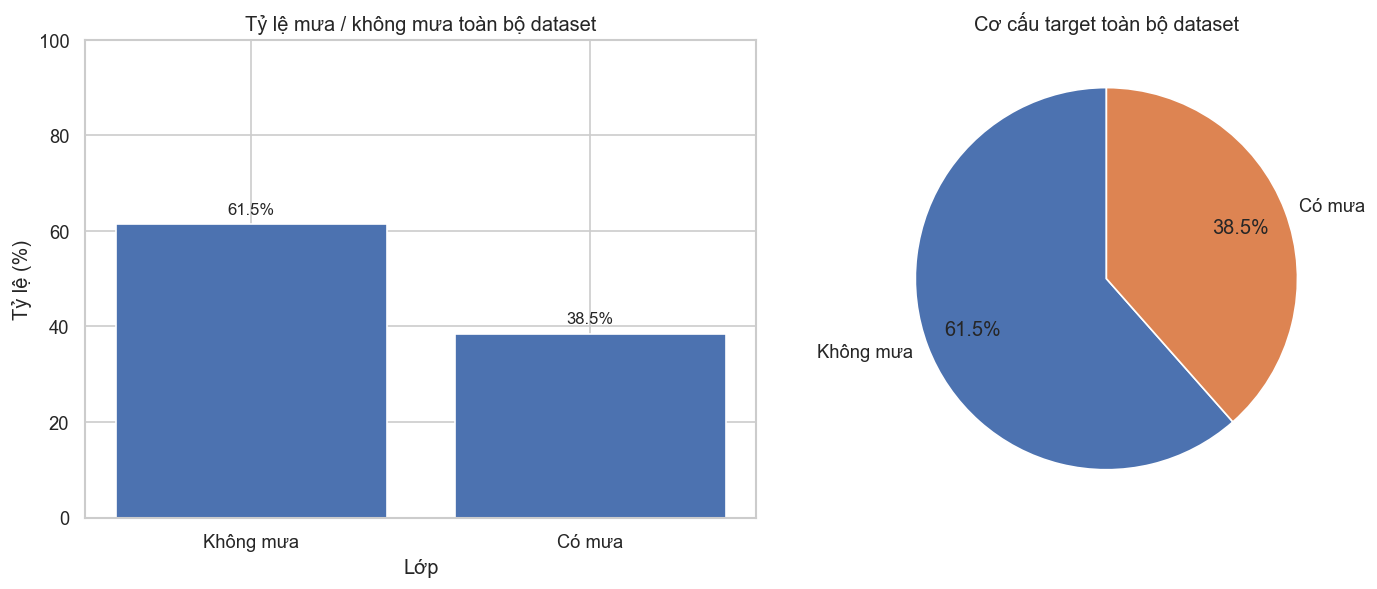

**Insight toàn bộ dataset:**  
- Tỷ lệ ngày mưa là **38.5%**, tỷ lệ ngày không mưa là **61.5%**.  
- Dataset có mất cân bằng nhẹ đến trung bình, nhưng chưa quá nghiêm trọng.  
- Accuracy vẫn có thể báo cáo, nhưng không nên là metric chính vì mô hình dự đoán lớp đa số vẫn có thể đạt accuracy khá.  
- Với bài toán xác suất mưa, nên ưu tiên **PR-AUC**, **Recall Rain**, **F1 Rain**, **F2 Rain** và **Brier Score**.

,station_name,PRCP_label,count,total,percent,label
0,CA MAU,0,2022,3651,55.382087,Không mưa
1,CA MAU,1,1629,3651,44.617913,Có mưa
2,HA DONG,0,2257,3651,61.818680,Không mưa
3,HA DONG,1,1394,3651,38.181320,Có mưa
4,NHA TRANG,0,2478,3651,67.871816,Không mưa
5,NHA TRANG,1,1173,3651,32.128184,Có mưa
6,QUANG NGAI,0,2189,3651,59.956176,Không mưa
7,QUANG NGAI,1,1462,3651,40.043824,Có mưa
8,VINH,0,2283,3651,62.530813,Không mưa
9,VINH,1,1368,3651,37.469187,Có mưa


label,Không mưa,Có mưa
station_name,,
NHA TRANG,67.871816,32.128184
VINH,62.530813,37.469187
HA DONG,61.818680,38.181320
QUANG NGAI,59.956176,40.043824
CA MAU,55.382087,44.617913


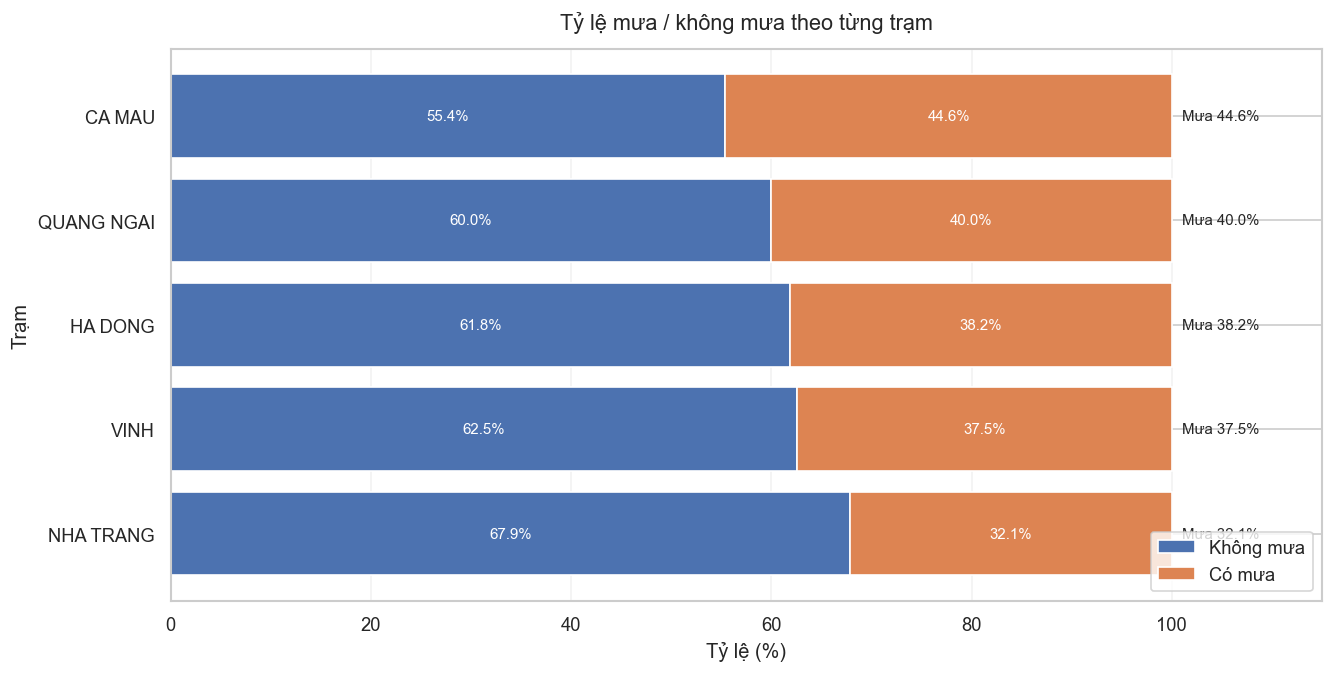

**Insight theo từng trạm:**  
- Trạm có tỷ lệ ngày mưa cao nhất là **CA MAU** với **44.6%** ngày mưa.  
- Trạm có tỷ lệ ngày mưa thấp nhất là **NHA TRANG** với **32.1%** ngày mưa.  
- Mức độ mất cân bằng lớp có khác nhau giữa các trạm, nhưng cả hai lớp đều vẫn có đủ dữ liệu để huấn luyện và đánh giá.  
- Không cần resampling riêng theo trạm; nên train một model tổng thể và đánh giá thêm metric theo từng trạm.  
- Accuracy có thể dùng để tham khảo theo từng trạm, nhưng vẫn nên đi kèm **Recall Rain**, **F1 Rain**, **PR-AUC** và **Brier Score**.

In [5]:
# ============================================================
# Phân tích target và mất cân bằng lớp
# ============================================================

target_counts = df[TARGET_COL].value_counts().sort_index()
target_percent = target_counts / target_counts.sum() * 100

target_summary = pd.DataFrame({
    "rain_target": target_counts.index,
    "count": target_counts.values,
    "percent": target_percent.values,
})

target_summary["label"] = target_summary["rain_target"].map({
    0: "Không mưa",
    1: "Có mưa"
})

display(target_summary)

# ----------------------------
# Biểu đồ tổng thể
# ----------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

# Bar chart tổng thể
bars = axes[0].bar(
    target_summary["label"],
    target_summary["percent"]
)

axes[0].set_title("Tỷ lệ mưa / không mưa toàn bộ dataset", fontsize=12)
axes[0].set_ylabel("Tỷ lệ (%)")
axes[0].set_xlabel("Lớp")
axes[0].set_ylim(0, max(100, target_summary["percent"].max() + 12))

for bar, v in zip(bars, target_summary["percent"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        v + 1.5,
        f"{v:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Pie chart tổng thể
axes[1].pie(
    target_summary["count"],
    labels=target_summary["label"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    labeldistance=1.08
)

axes[1].set_title("Cơ cấu target toàn bộ dataset", fontsize=12)

plt.show()

rain_rate = target_percent.get(1, 0)
no_rain_rate = target_percent.get(0, 0)

msg = (
    f"**Insight toàn bộ dataset:**  \n"
    f"- Tỷ lệ ngày mưa là **{rain_rate:.1f}%**, tỷ lệ ngày không mưa là **{no_rain_rate:.1f}%**.  \n"
    "- Dataset có mất cân bằng nhẹ đến trung bình, nhưng chưa quá nghiêm trọng.  \n"
    "- Accuracy vẫn có thể báo cáo, nhưng không nên là metric chính vì mô hình dự đoán lớp đa số vẫn có thể đạt accuracy khá.  \n"
    "- Với bài toán xác suất mưa, nên ưu tiên **PR-AUC**, **Recall Rain**, **F1 Rain**, **F2 Rain** và **Brier Score**."
)

display(Markdown(msg))


# ============================================================
# Phân tích target theo từng trạm
# ============================================================

if "STATION" in df.columns:
    station_target = df.copy()

    # Map mã trạm sang tên trạm nếu chưa có station_name
    if "station_name" not in station_target.columns:
        station_name_map = {
            "48825099999": "HA DONG",
            "48845099999": "VINH",
            "48863099999": "QUANG NGAI",
            "48877099999": "NHA TRANG",
            "48914099999": "CA MAU",
        }

        station_target["station_name"] = (
            station_target["STATION"]
            .astype(str)
            .map(station_name_map)
            .fillna(station_target["STATION"].astype(str))
        )

    station_target[TARGET_COL] = pd.to_numeric(
        station_target[TARGET_COL],
        errors="coerce"
    )

    # Tính số lượng theo trạm và target
    station_target_summary = (
        station_target
        .dropna(subset=["station_name", TARGET_COL])
        .groupby(["station_name", TARGET_COL])
        .size()
        .reset_index(name="count")
    )

    station_total = (
        station_target
        .dropna(subset=["station_name", TARGET_COL])
        .groupby("station_name")
        .size()
        .reset_index(name="total")
    )

    station_target_summary = station_target_summary.merge(
        station_total,
        on="station_name",
        how="left"
    )

    station_target_summary["percent"] = (
        station_target_summary["count"] / station_target_summary["total"] * 100
    )

    station_target_summary["label"] = station_target_summary[TARGET_COL].map({
        0: "Không mưa",
        1: "Có mưa"
    })

    display(station_target_summary)

    # Pivot để vẽ stacked bar
    station_pivot = station_target_summary.pivot(
        index="station_name",
        columns="label",
        values="percent"
    ).fillna(0)

    for col in ["Không mưa", "Có mưa"]:
        if col not in station_pivot.columns:
            station_pivot[col] = 0

    station_pivot = station_pivot[["Không mưa", "Có mưa"]]
    station_pivot = station_pivot.sort_values("Có mưa", ascending=True)

    display(station_pivot)

    # ----------------------------
    # Horizontal stacked bar theo trạm
    # ----------------------------

    fig, ax = plt.subplots(figsize=(11, 5.5), constrained_layout=True)

    y_pos = np.arange(len(station_pivot))

    ax.barh(
        y_pos,
        station_pivot["Không mưa"],
        label="Không mưa"
    )

    ax.barh(
        y_pos,
        station_pivot["Có mưa"],
        left=station_pivot["Không mưa"],
        label="Có mưa"
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(station_pivot.index)
    ax.set_xlim(0, 100)

    ax.set_title("Tỷ lệ mưa / không mưa theo từng trạm", fontsize=13, pad=12)
    ax.set_xlabel("Tỷ lệ (%)")
    ax.set_ylabel("Trạm")
    ax.legend(loc="lower right")

    # Ghi nhãn phần trăm ngay trong thanh để tránh chồng lấn
    for i, station in enumerate(station_pivot.index):
        no_rain_percent = station_pivot.loc[station, "Không mưa"]
        rain_percent = station_pivot.loc[station, "Có mưa"]

        if no_rain_percent > 8:
            ax.text(
                no_rain_percent / 2,
                i,
                f"{no_rain_percent:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="white"
            )

        if rain_percent > 8:
            ax.text(
                no_rain_percent + rain_percent / 2,
                i,
                f"{rain_percent:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="white"
            )

        # Ghi tỷ lệ mưa ở ngoài cùng bên phải cho dễ so sánh
        ax.text(
            101,
            i,
            f"Mưa {rain_percent:.1f}%",
            ha="left",
            va="center",
            fontsize=9
        )

    ax.set_xlim(0, 115)
    ax.grid(axis="x", alpha=0.25)

    plt.show()

    max_rain_station = station_pivot["Có mưa"].idxmax()
    min_rain_station = station_pivot["Có mưa"].idxmin()

    max_rain_value = station_pivot.loc[max_rain_station, "Có mưa"]
    min_rain_value = station_pivot.loc[min_rain_station, "Có mưa"]

    msg_station = (
        f"**Insight theo từng trạm:**  \n"
        f"- Trạm có tỷ lệ ngày mưa cao nhất là **{max_rain_station}** với **{max_rain_value:.1f}%** ngày mưa.  \n"
        f"- Trạm có tỷ lệ ngày mưa thấp nhất là **{min_rain_station}** với **{min_rain_value:.1f}%** ngày mưa.  \n"
        "- Mức độ mất cân bằng lớp có khác nhau giữa các trạm, nhưng cả hai lớp đều vẫn có đủ dữ liệu để huấn luyện và đánh giá.  \n"
        "- Không cần resampling riêng theo trạm; nên train một model tổng thể và đánh giá thêm metric theo từng trạm.  \n"
        "- Accuracy có thể dùng để tham khảo theo từng trạm, nhưng vẫn nên đi kèm **Recall Rain**, **F1 Rain**, **PR-AUC** và **Brier Score**."
    )

    display(Markdown(msg_station))

## 4. Xác suất mưa theo tháng


,month,rain_probability_percent
0,1,33.376623
1,2,24.805654
2,3,21.548387
3,4,23.000000
4,5,34.838710
5,6,34.733333
6,7,42.064516
7,8,43.677419
8,9,52.200000
9,10,57.548387


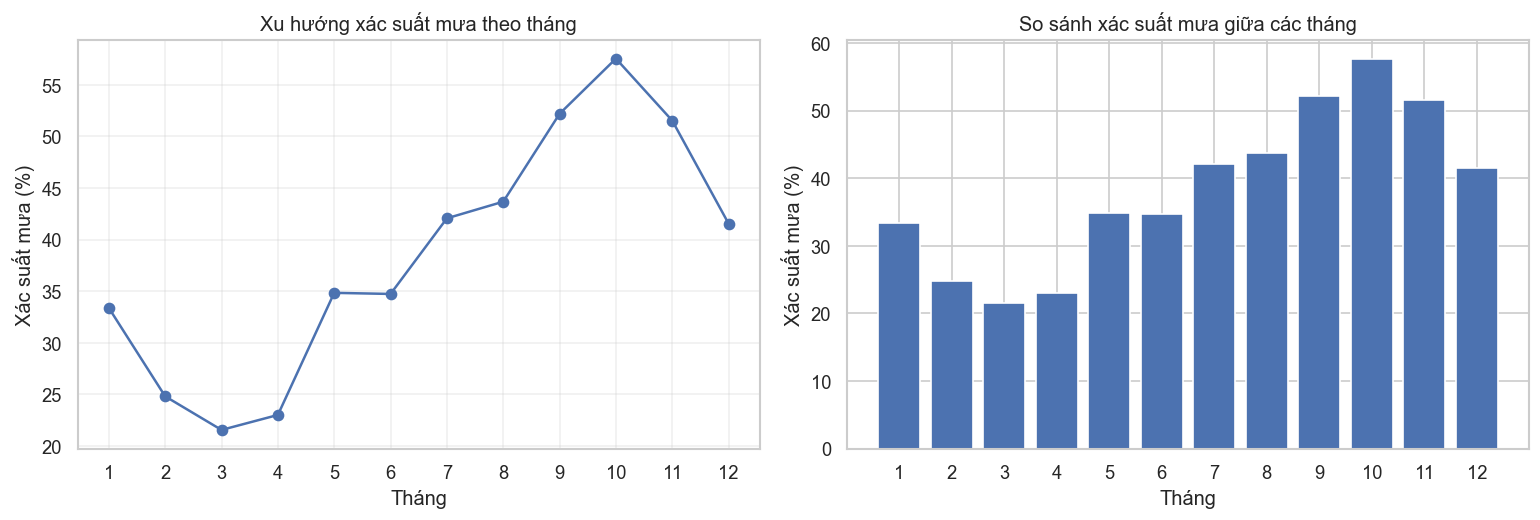

**Insight:**  \n- Xác suất mưa thay đổi theo tháng, cho thấy dữ liệu có tính mùa vụ.  \n- Tháng có xác suất mưa cao nhất: **tháng 10**.  \n- Tháng có xác suất mưa thấp nhất: **tháng 3**.  \n- Vì mưa có tính chu kỳ theo mùa, nên giữ `day_sin`, `day_cos`, `month_sin`, `month_cos` là hợp lý hơn dùng tháng dạng số nguyên.

In [7]:
time_df = df.copy()
time_df["month"] = time_df["time"].dt.month

monthly_rain = (
    time_df
    .groupby("month", as_index=False)[TARGET_COL]
    .mean()
)
monthly_rain["rain_probability_percent"] = monthly_rain[TARGET_COL] * 100

display(monthly_rain[["month", "rain_probability_percent"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(
    monthly_rain["month"],
    monthly_rain["rain_probability_percent"],
    marker="o",
)
axes[0].set_title("Xu hướng xác suất mưa theo tháng")
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Xác suất mưa (%)")
axes[0].set_xticks(range(1, 13))
axes[0].grid(alpha=0.3)

axes[1].bar(
    monthly_rain["month"].astype(str),
    monthly_rain["rain_probability_percent"],
)
axes[1].set_title("So sánh xác suất mưa giữa các tháng")
axes[1].set_xlabel("Tháng")
axes[1].set_ylabel("Xác suất mưa (%)")

plt.tight_layout()
plt.show()

max_month = int(monthly_rain.loc[monthly_rain["rain_probability_percent"].idxmax(), "month"])
min_month = int(monthly_rain.loc[monthly_rain["rain_probability_percent"].idxmin(), "month"])

msg = (
    "**Insight:**  \\n"
    "- Xác suất mưa thay đổi theo tháng, cho thấy dữ liệu có tính mùa vụ.  \\n"
    f"- Tháng có xác suất mưa cao nhất: **tháng {max_month}**.  \\n"
    f"- Tháng có xác suất mưa thấp nhất: **tháng {min_month}**.  \\n"
    "- Vì mưa có tính chu kỳ theo mùa, nên giữ `day_sin`, `day_cos`, `month_sin`, `month_cos` là hợp lý hơn dùng tháng dạng số nguyên."
)
display(Markdown(msg))


## 5. Xác suất mưa theo trạm và tháng


month,1,2,3,4,5,6,7,8,9,10,11,12
station_name,,,,,,,,,,,,
CA MAU,12.337662,6.007067,5.483871,20.666667,53.548387,63.333333,68.387097,68.709677,74.666667,76.129032,55.000000,28.709677
HA DONG,29.870130,32.155477,38.064516,39.666667,46.129032,47.000000,50.322581,54.838710,49.000000,33.225806,21.000000,16.451613
NHA TRANG,28.571429,14.134276,11.290323,12.000000,23.548387,24.000000,25.161290,26.774194,44.333333,60.000000,63.333333,51.290323
QUANG NGAI,56.493506,31.802120,16.129032,12.333333,21.612903,20.333333,34.193548,30.967742,45.333333,63.225806,73.666667,73.548387
VINH,39.610390,39.929329,36.774194,30.333333,29.354839,19.000000,32.258065,37.096774,47.666667,55.161290,44.666667,37.741935


,station_name,rain_probability_percent
0,CA MAU,44.617913
3,QUANG NGAI,40.043824
1,HA DONG,38.181320
4,VINH,37.469187
2,NHA TRANG,32.128184


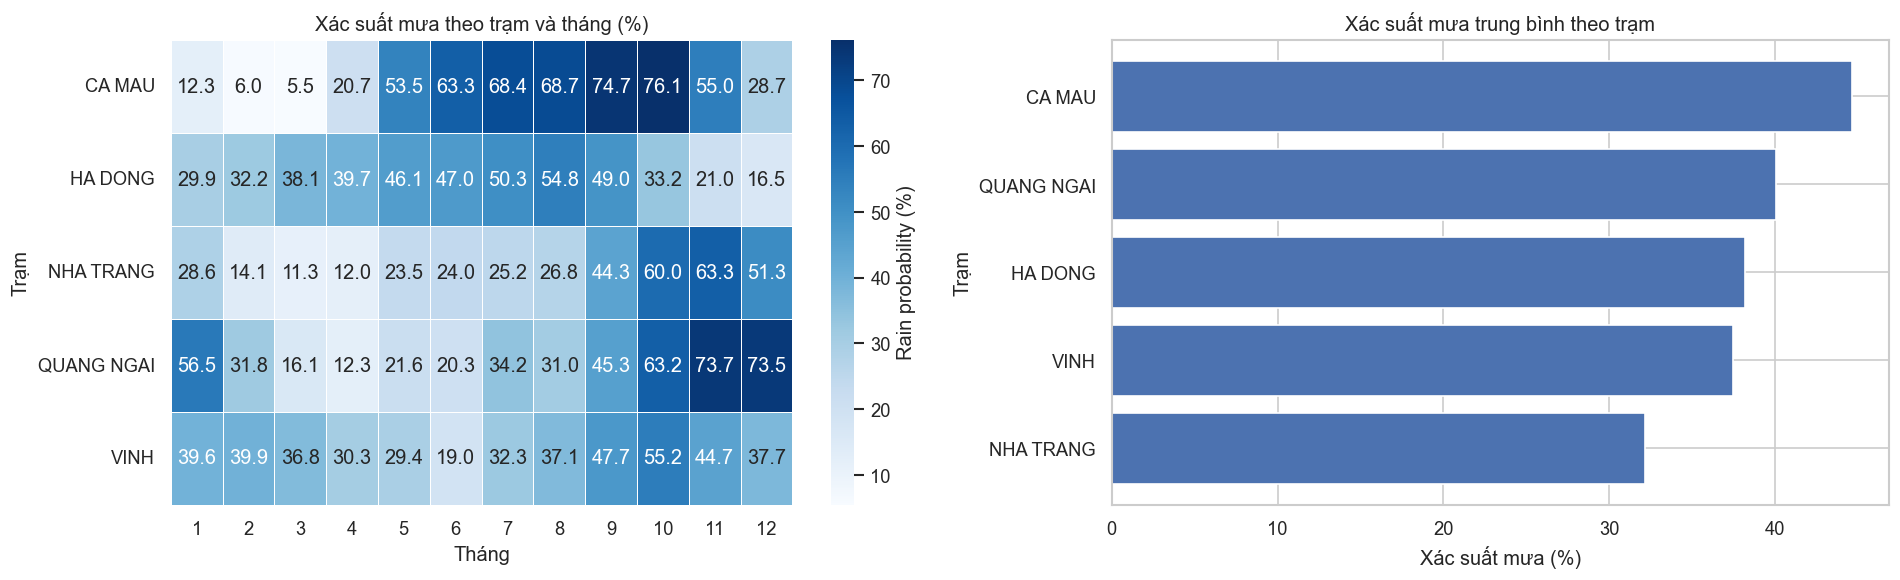

**Insight:**  \n- Trạm có xác suất mưa trung bình cao nhất: **CA MAU**.  \n- Trạm có xác suất mưa trung bình thấp nhất: **NHA TRANG**.  \n- Có sự khác biệt không gian giữa các trạm, vì vậy các biến `LATITUDE`, `LONGITUDE`, `ELEVATION` có thể giữ lại để mô hình nhận biết khác biệt vùng/địa hình.  \n- Khi báo cáo cần nói rõ đây là bài toán đánh giá trên cùng nhóm trạm theo thời gian, không phải generalize sang trạm hoàn toàn mới.

In [8]:
station_month = (
    time_df
    .groupby(["station_name", "month"], as_index=False)[TARGET_COL]
    .mean()
)
station_month["rain_probability_percent"] = station_month[TARGET_COL] * 100

station_month_pivot = station_month.pivot(
    index="station_name",
    columns="month",
    values="rain_probability_percent"
)

station_month_pivot = (
    station_month_pivot
    .reindex(columns=range(1, 13))
    .apply(pd.to_numeric, errors="coerce")
    .astype(float)
)

station_mean = (
    df.groupby("station_name", as_index=False)[TARGET_COL]
    .mean()
)
station_mean["rain_probability_percent"] = station_mean[TARGET_COL] * 100
station_mean = station_mean.sort_values("rain_probability_percent", ascending=False)

display(station_month_pivot)
display(station_mean[["station_name", "rain_probability_percent"]])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if HAS_SEABORN:
    sns.heatmap(
        station_month_pivot,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        linewidths=0.5,
        cbar_kws={"label": "Rain probability (%)"},
        ax=axes[0],
    )
else:
    im = axes[0].imshow(station_month_pivot.values.astype(float), aspect="auto")
    axes[0].set_xticks(range(station_month_pivot.shape[1]))
    axes[0].set_xticklabels(station_month_pivot.columns)
    axes[0].set_yticks(range(station_month_pivot.shape[0]))
    axes[0].set_yticklabels(station_month_pivot.index)
    fig.colorbar(im, ax=axes[0], label="Rain probability (%)")

axes[0].set_title("Xác suất mưa theo trạm và tháng (%)")
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Trạm")

axes[1].barh(
    station_mean["station_name"][::-1],
    station_mean["rain_probability_percent"][::-1],
)
axes[1].set_title("Xác suất mưa trung bình theo trạm")
axes[1].set_xlabel("Xác suất mưa (%)")
axes[1].set_ylabel("Trạm")

plt.tight_layout()
plt.show()

top_station = station_mean.iloc[0]["station_name"]
bottom_station = station_mean.iloc[-1]["station_name"]

msg = (
    "**Insight:**  \\n"
    f"- Trạm có xác suất mưa trung bình cao nhất: **{top_station}**.  \\n"
    f"- Trạm có xác suất mưa trung bình thấp nhất: **{bottom_station}**.  \\n"
    "- Có sự khác biệt không gian giữa các trạm, vì vậy các biến `LATITUDE`, `LONGITUDE`, `ELEVATION` có thể giữ lại để mô hình nhận biết khác biệt vùng/địa hình.  \\n"
    "- Khi báo cáo cần nói rõ đây là bài toán đánh giá trên cùng nhóm trạm theo thời gian, không phải generalize sang trạm hoàn toàn mới."
)
display(Markdown(msg))


## 5.1. Phân tích lượng mưa cho Stage 2 Regression

Vì bài toán là two-stage, ngoài `PRCP_label` cho Stage 1, cần kiểm tra phân phối `PRCP` và `PRCP_log1p` trên các ngày mưa để giải thích vì sao Stage 2 dùng hồi quy riêng cho lượng mưa.

,n_total_days,n_rainy_days,rainy_day_rate_%,prcp_mean_rainy_mm,prcp_median_rainy_mm,prcp_max_mm
0,18255,7026,38.488,14.896308,4.572,381.254


### Percentile lượng mưa trên ngày mưa

,percentile,PRCP_mm
0,50%,4.572
1,75%,16.002
2,90%,39.751
3,95%,60.706
4,99%,143.891


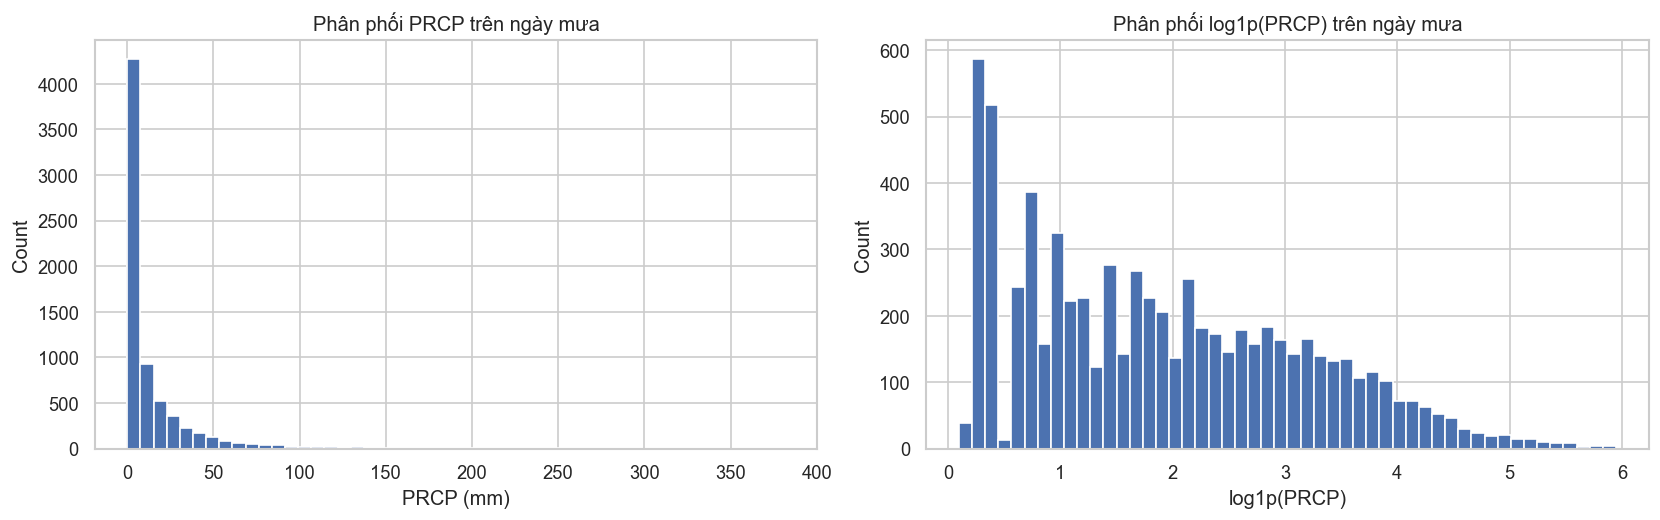

### Lượng mưa ngày mưa theo trạm

,STATION,station_name,n_rainy_days,median_prcp_mm,mean_prcp_mm,p90_prcp_mm
4,48914099999,CA MAU,1629,7.112,14.034914,35.5600
2,48863099999,QUANG NGAI,1462,5.080,17.871895,46.4312
0,48825099999,HA DONG,1394,3.810,12.683908,36.0680
1,48845099999,VINH,1368,4.064,16.884638,45.7962
3,48877099999,NHA TRANG,1173,3.302,12.694221,35.3060


**Insight Stage 2:**  
- `PRCP` trên các ngày mưa thường lệch phải, có nhiều ngày mưa nhỏ và một số ngày mưa lớn.  
- `log1p(PRCP)` giúp phân phối bớt lệch hơn, phù hợp để train regressor ổn định hơn.  
- Đây là lý do pipeline dùng two-stage: Stage 1 dự đoán xác suất mưa, Stage 2 chỉ học lượng mưa có điều kiện trên ngày mưa.

In [9]:
# ============================================================
# STAGE 2 TARGET ANALYSIS: RAINFALL AMOUNT
# ============================================================

if "PRCP" not in df.columns:
    display(Markdown("Không có cột PRCP nên không thể phân tích Stage 2 rainfall amount."))
else:
    prcp_df = df.copy()
    prcp_df["PRCP"] = pd.to_numeric(prcp_df["PRCP"], errors="coerce").fillna(0).clip(lower=0)
    prcp_df["is_rainy_day"] = prcp_df["PRCP"] > 0.1

    rainy_df = prcp_df[prcp_df["is_rainy_day"]].copy()

    rainfall_summary = pd.DataFrame([{
        "n_total_days": len(prcp_df),
        "n_rainy_days": len(rainy_df),
        "rainy_day_rate_%": round(len(rainy_df) / len(prcp_df) * 100, 3),
        "prcp_mean_rainy_mm": rainy_df["PRCP"].mean(),
        "prcp_median_rainy_mm": rainy_df["PRCP"].median(),
        "prcp_max_mm": prcp_df["PRCP"].max(),
    }])

    display(rainfall_summary)

    if not rainy_df.empty:
        percentiles = [0.50, 0.75, 0.90, 0.95, 0.99]
        rainfall_percentiles = (
            rainy_df["PRCP"]
            .quantile(percentiles)
            .rename("PRCP_mm")
            .reset_index()
            .rename(columns={"index": "percentile"})
        )
        rainfall_percentiles["percentile"] = (rainfall_percentiles["percentile"] * 100).astype(int).astype(str) + "%"
        display(Markdown("### Percentile lượng mưa trên ngày mưa"))
        display(rainfall_percentiles)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

        axes[0].hist(rainy_df["PRCP"], bins=50)
        axes[0].set_title("Phân phối PRCP trên ngày mưa")
        axes[0].set_xlabel("PRCP (mm)")
        axes[0].set_ylabel("Count")

        log_prcp = np.log1p(rainy_df["PRCP"])
        axes[1].hist(log_prcp, bins=50)
        axes[1].set_title("Phân phối log1p(PRCP) trên ngày mưa")
        axes[1].set_xlabel("log1p(PRCP)")
        axes[1].set_ylabel("Count")

        plt.tight_layout()
        plt.show()

        if "STATION" in rainy_df.columns:
            rainy_by_station = (
                rainy_df
                .groupby("STATION")
                .agg(
                    station_name=("station_name", "first") if "station_name" in rainy_df.columns else ("STATION", "first"),
                    n_rainy_days=("PRCP", "size"),
                    median_prcp_mm=("PRCP", "median"),
                    mean_prcp_mm=("PRCP", "mean"),
                    p90_prcp_mm=("PRCP", lambda x: x.quantile(0.90)),
                )
                .reset_index()
                .sort_values("n_rainy_days", ascending=False)
            )
            display(Markdown("### Lượng mưa ngày mưa theo trạm"))
            display(rainy_by_station)

        display(Markdown(
            "**Insight Stage 2:**  \n"
            "- `PRCP` trên các ngày mưa thường lệch phải, có nhiều ngày mưa nhỏ và một số ngày mưa lớn.  \n"
            "- `log1p(PRCP)` giúp phân phối bớt lệch hơn, phù hợp để train regressor ổn định hơn.  \n"
            "- Đây là lý do pipeline dùng two-stage: Stage 1 dự đoán xác suất mưa, Stage 2 chỉ học lượng mưa có điều kiện trên ngày mưa."
        ))


## 6. Phân phối feature theo target


### 6.1. Phân phối toàn bộ feature numeric


Số feature numeric hợp lệ: **70**.  \nĐể notebook gọn, phần này vẽ tối đa **32 feature** đầu tiên.  \nPhần 6.2 bên dưới sẽ tập trung vào các feature có phân phối khác biệt rõ nhất giữa mưa và không mưa.

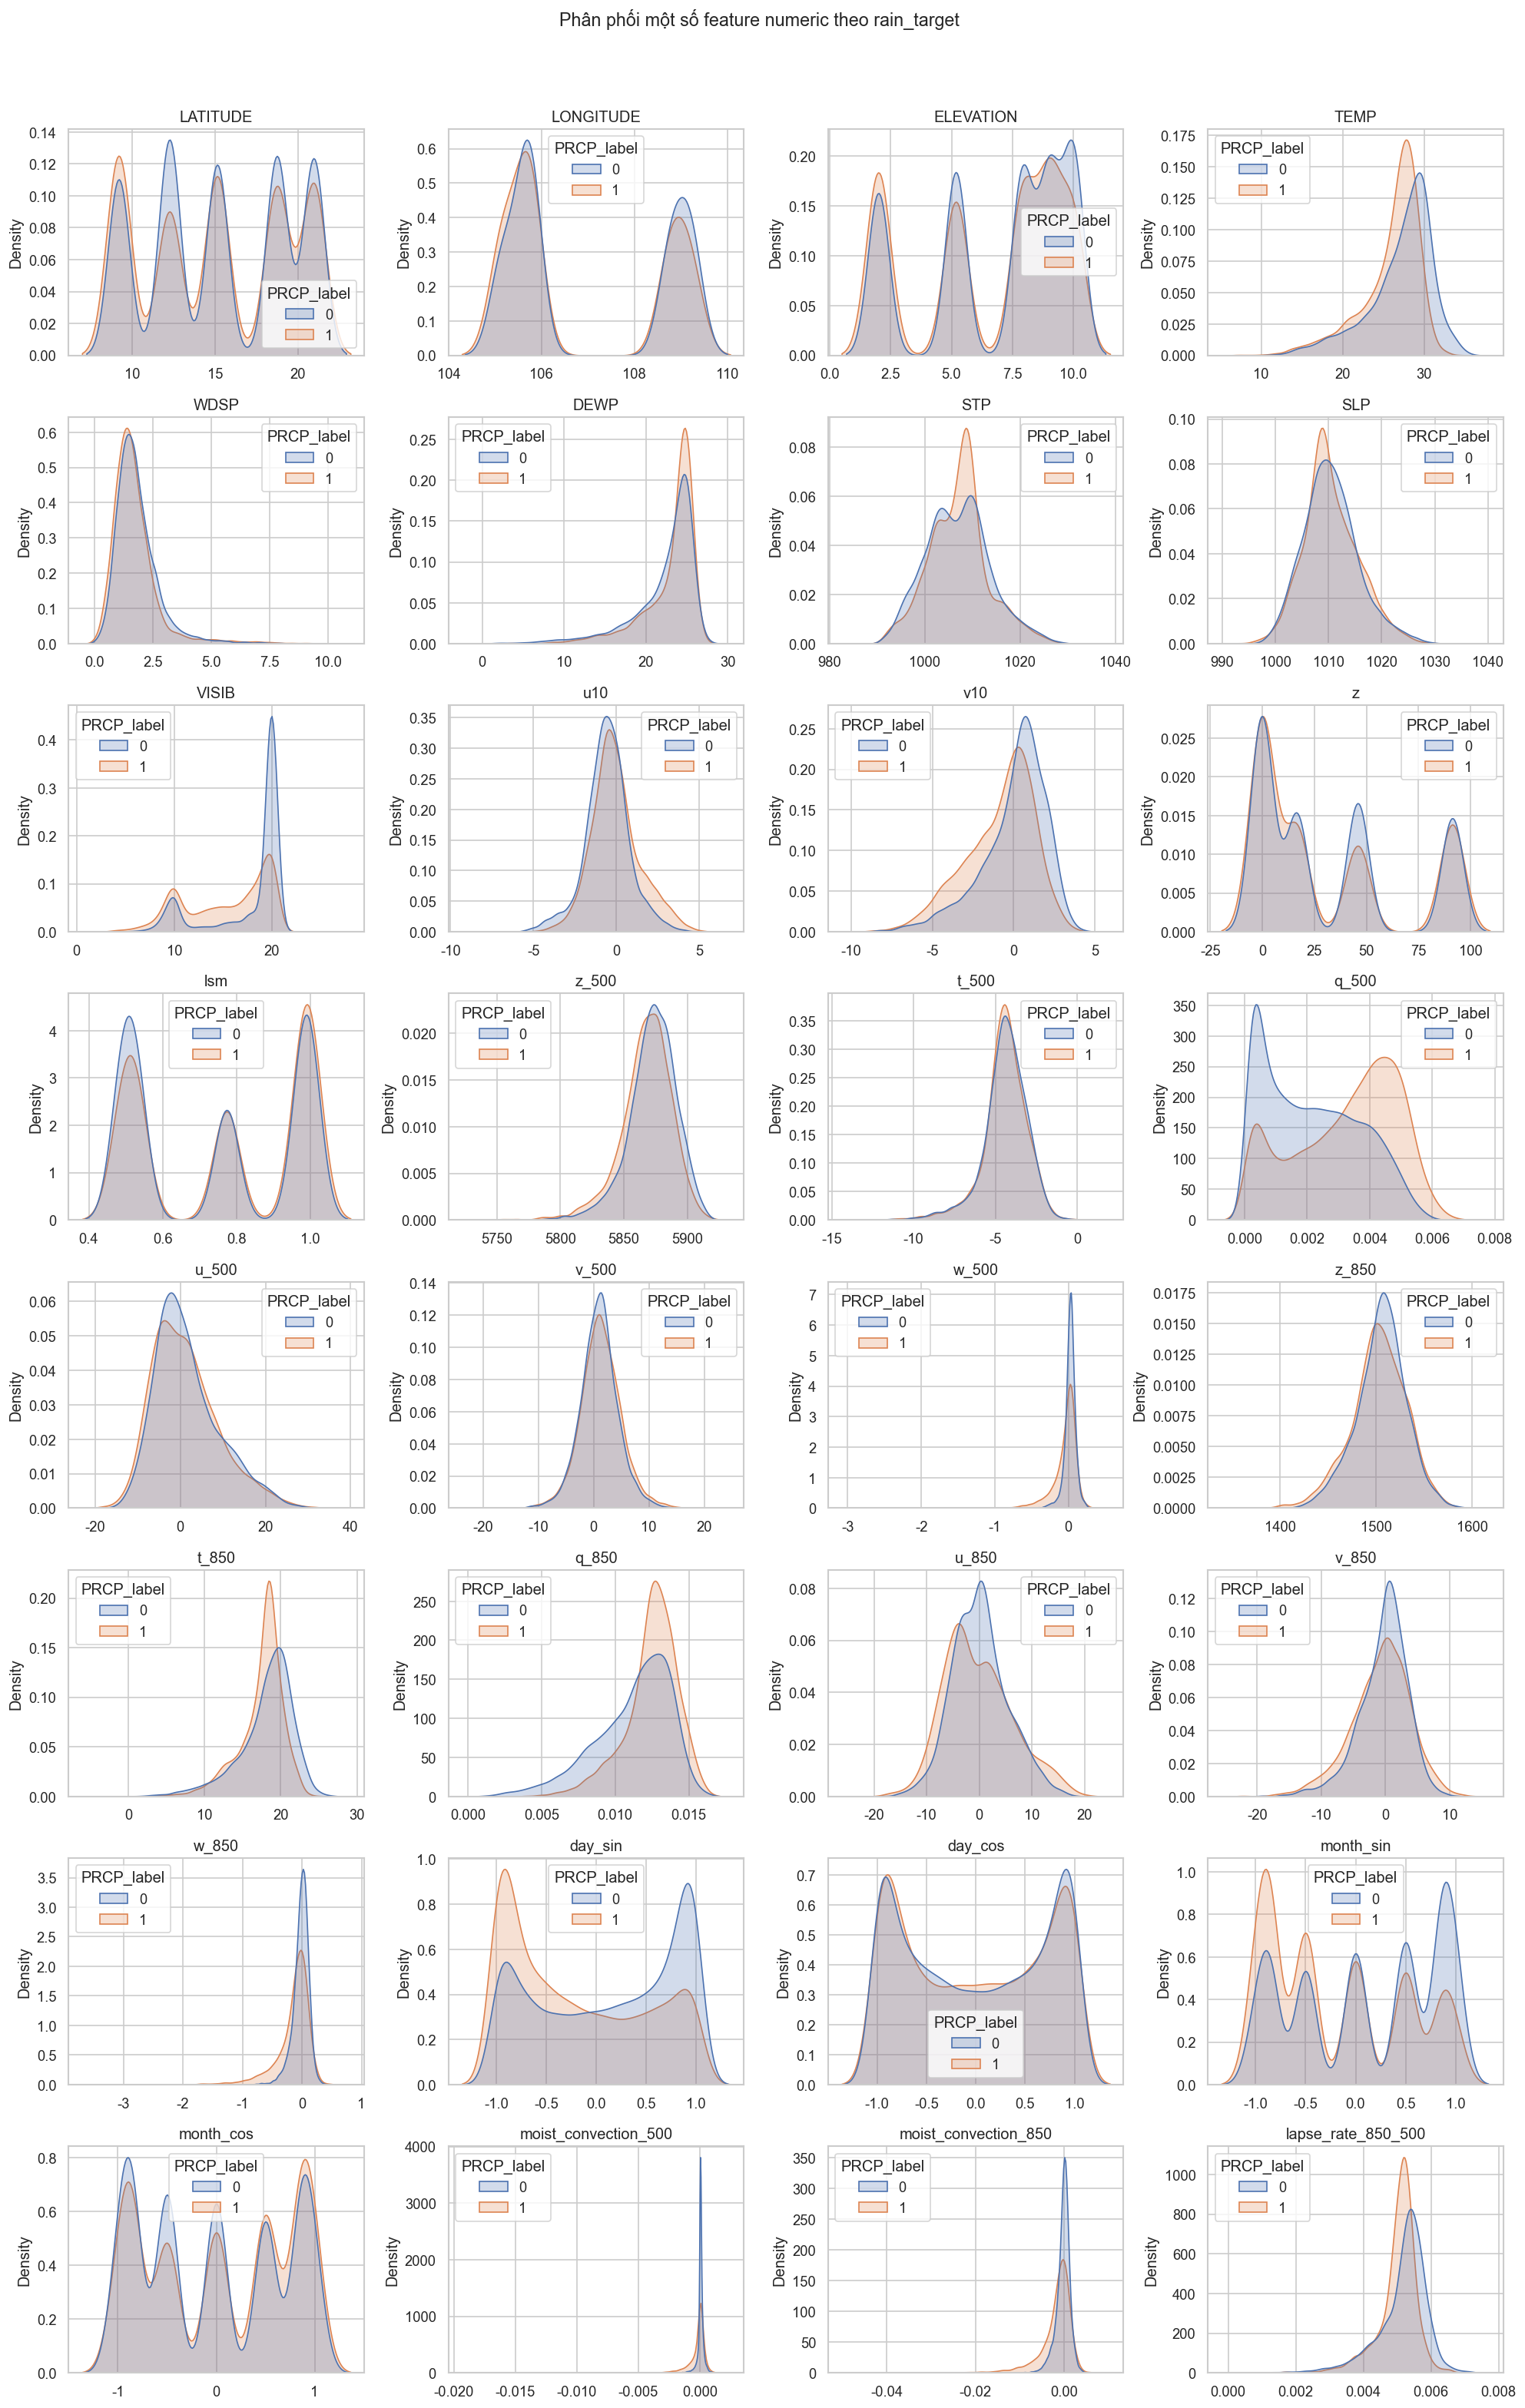

In [10]:
all_plot_features = FEATURE_COLS[:32]

msg = (
    f"Số feature numeric hợp lệ: **{len(FEATURE_COLS)}**.  \\n"
    f"Để notebook gọn, phần này vẽ tối đa **{len(all_plot_features)} feature** đầu tiên.  \\n"
    "Phần 6.2 bên dưới sẽ tập trung vào các feature có phân phối khác biệt rõ nhất giữa mưa và không mưa."
)
display(Markdown(msg))

plot_distribution_by_target(
    df,
    all_plot_features,
    target_col=TARGET_COL,
    n_cols=4,
    title_prefix="Phân phối một số feature numeric theo rain_target"
)


### 6.2. Feature có phân phối lệch rõ giữa mưa và không mưa


,feature,median_no_rain,median_rain,median_diff,standardized_median_diff,abs_standardized_median_diff,p_value,minus_log10_p
0,dew_point_depression,4.722200e+00,2.833300,-1.888900,-1.171056,1.171056,0.000000e+00,300.000000
1,q_500,2.000000e-03,0.003600,0.001600,1.008133,1.008133,0.000000e+00,300.000000
2,dew_point_depression_3d_mean,4.574067e+00,3.148133,-1.425933,-0.955771,0.955771,0.000000e+00,300.000000
3,VISIB,1.995580e+01,16.254300,-3.701500,-0.903592,0.903592,0.000000e+00,300.000000
4,VISIB_lag_1,1.995580e+01,16.254300,-3.701500,-0.899030,0.899030,0.000000e+00,300.000000
5,day_sin,2.303057e-01,-0.361714,-0.592019,-0.861592,0.861592,1.337413e-203,202.873735
6,dew_point_depression_lag_1,4.555600e+00,3.111100,-1.444500,-0.834108,0.834108,0.000000e+00,300.000000
7,VISIB_3d_mean,1.958030e+01,16.737167,-2.843133,-0.750200,0.750200,0.000000e+00,300.000000
8,month_sin,1.224647e-16,-0.500000,-0.500000,-0.729086,0.729086,1.686126e-198,197.773110
9,moisture_flux_850,5.225633e-02,0.078713,0.026457,0.569668,0.569668,5.269270e-300,299.278250


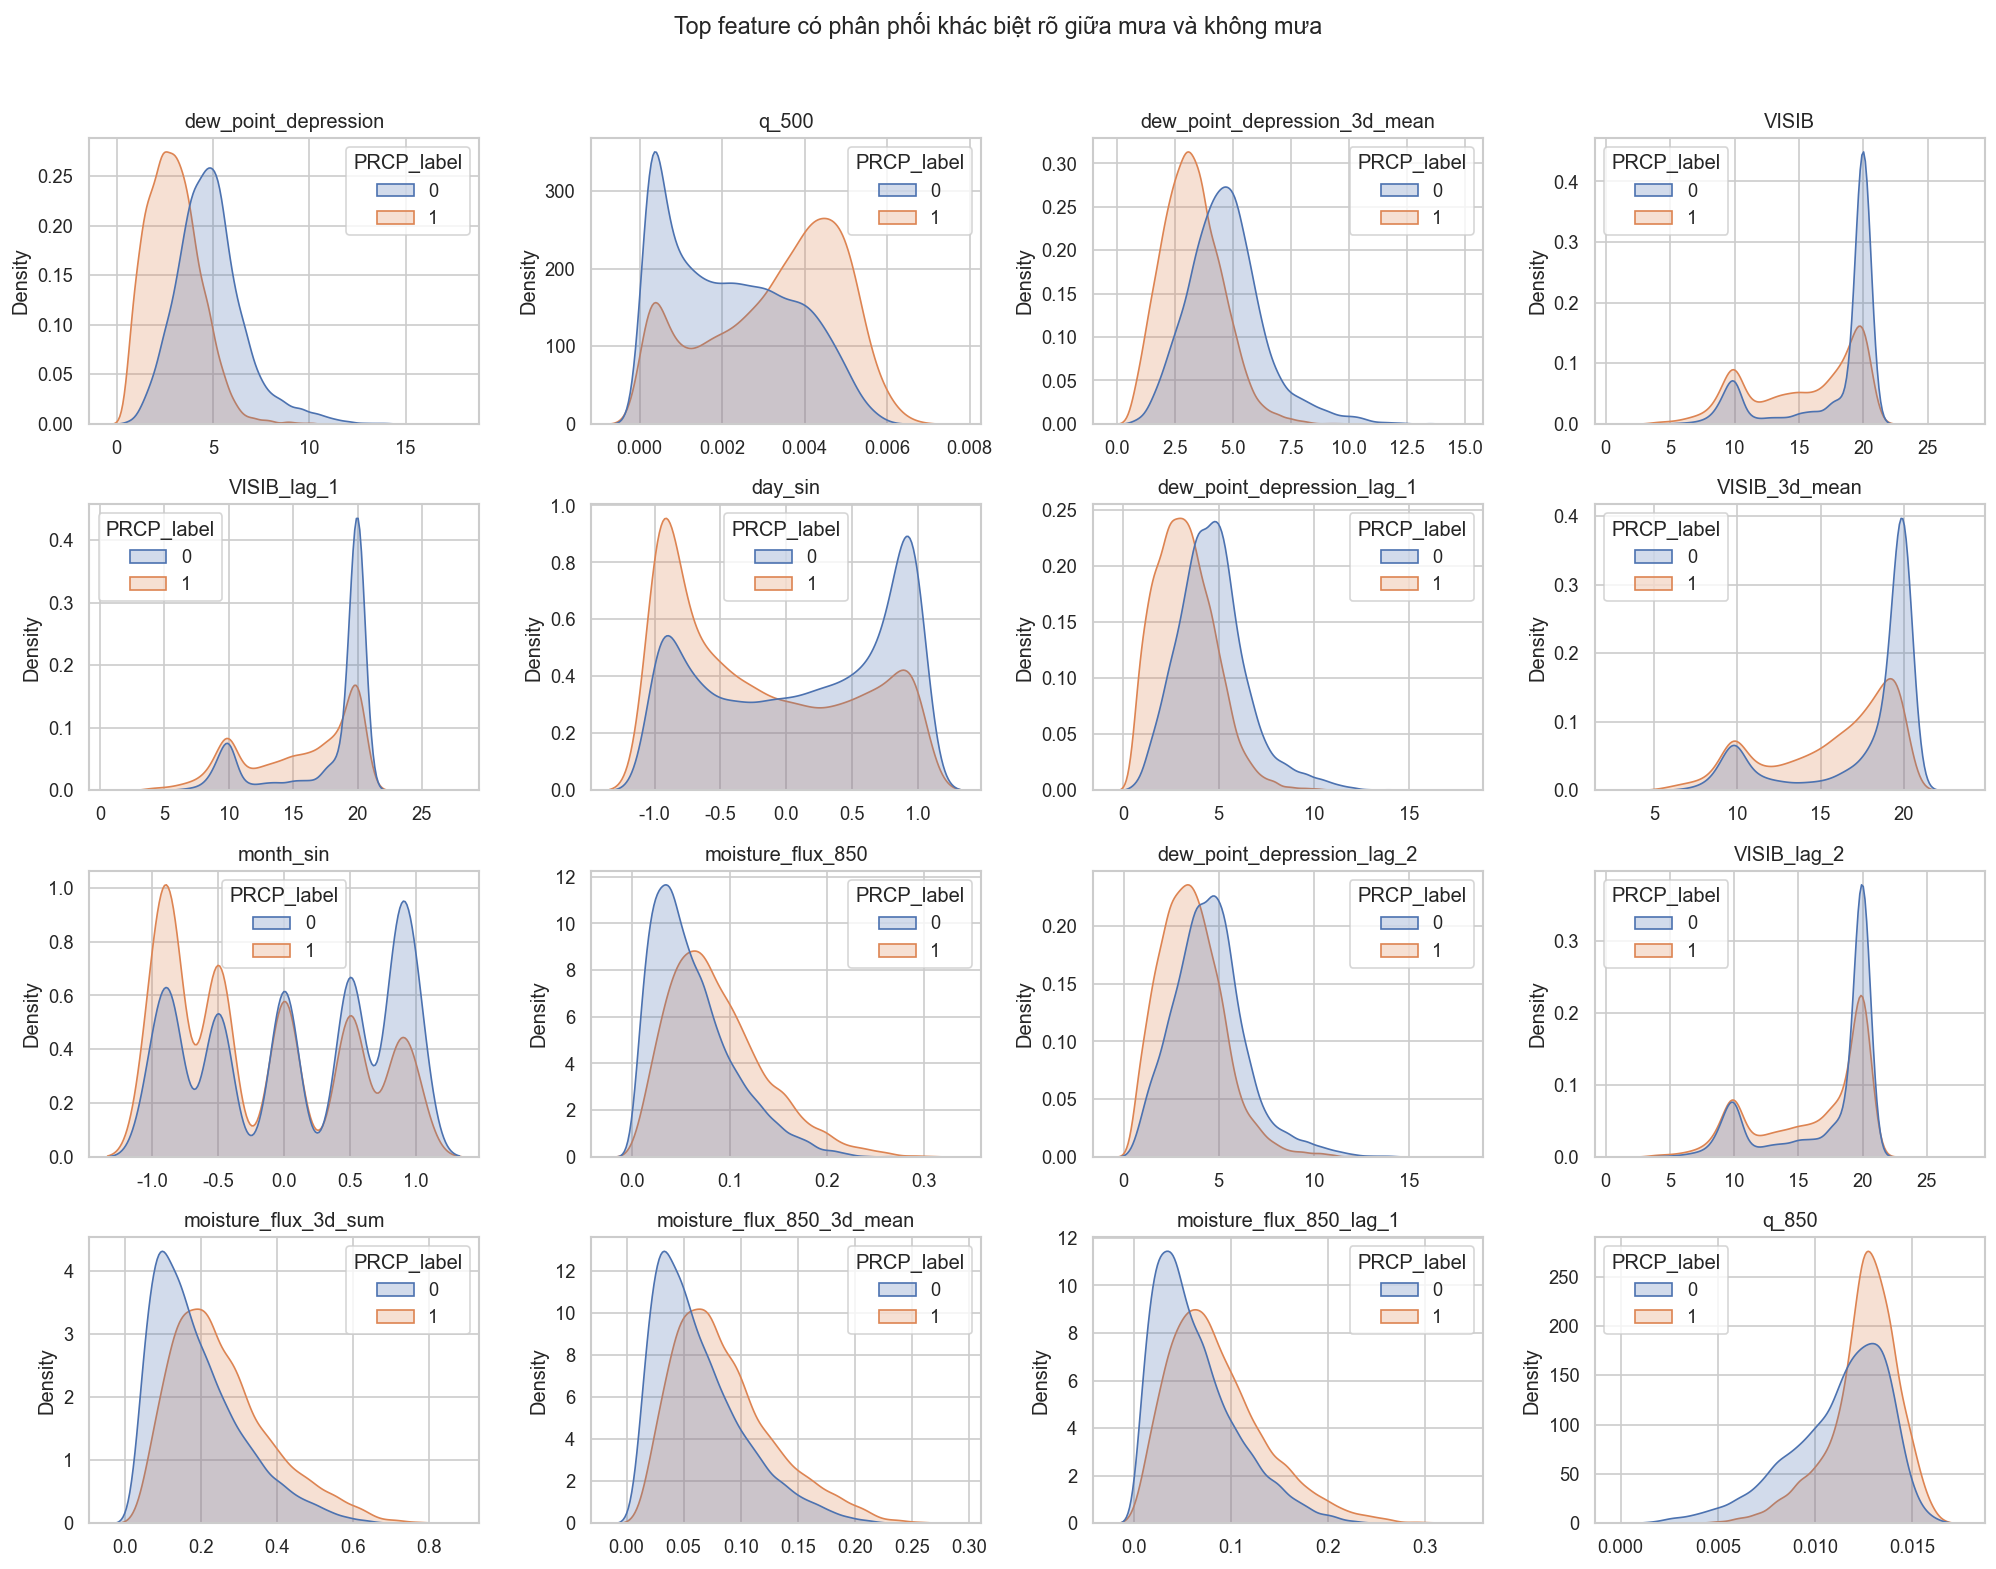

**Insight:**  \nCác feature có phân phối lệch rõ giữa nhóm mưa và không mưa thường là ứng viên tốt cho model.  \nCần ưu tiên giải thích các feature có ý nghĩa khí tượng như độ ẩm, điểm sương, visibility, moisture flux, chuyển động thẳng đứng và lượng mưa quá khứ.

In [11]:
distribution_rows = []

for col in FEATURE_COLS:
    s = safe_numeric(df[col])
    y = safe_numeric(df[TARGET_COL])

    group_0 = s[(y == 0) & s.notna()]
    group_1 = s[(y == 1) & s.notna()]

    if len(group_0) < 20 or len(group_1) < 20:
        continue

    pooled_std = np.sqrt((group_0.var() + group_1.var()) / 2)
    if pooled_std == 0 or pd.isna(pooled_std):
        standardized_diff = 0
    else:
        standardized_diff = (group_1.median() - group_0.median()) / pooled_std

    try:
        _, p_value = mannwhitneyu(group_0, group_1, alternative="two-sided")
    except Exception:
        p_value = np.nan

    distribution_rows.append({
        "feature": col,
        "median_no_rain": group_0.median(),
        "median_rain": group_1.median(),
        "median_diff": group_1.median() - group_0.median(),
        "standardized_median_diff": standardized_diff,
        "abs_standardized_median_diff": abs(standardized_diff),
        "p_value": p_value,
        "minus_log10_p": -np.log10(max(p_value, 1e-300)) if pd.notna(p_value) else np.nan,
    })

distribution_diff_df = (
    pd.DataFrame(distribution_rows)
    .sort_values(["abs_standardized_median_diff", "minus_log10_p"], ascending=[False, False])
    .reset_index(drop=True)
)

display(distribution_diff_df.head(20))

top_distribution_features = distribution_diff_df.head(16)["feature"].tolist()

plot_distribution_by_target(
    df,
    top_distribution_features,
    target_col=TARGET_COL,
    n_cols=4,
    title_prefix="Top feature có phân phối khác biệt rõ giữa mưa và không mưa"
)

display(Markdown(
    "**Insight:**  \\n"
    "Các feature có phân phối lệch rõ giữa nhóm mưa và không mưa thường là ứng viên tốt cho model.  \\n"
    "Cần ưu tiên giải thích các feature có ý nghĩa khí tượng như độ ẩm, điểm sương, visibility, moisture flux, chuyển động thẳng đứng và lượng mưa quá khứ."
))


## 7. Phân tích mối liên hệ giữa feature và PRCP_label


### Top feature theo Spearman correlation

,feature,pearson_corr,spearman_corr,abs_spearman_corr
0,dew_point_depression,-0.489624,-0.525128,0.525128
1,dew_point_depression_3d_mean,-0.418274,-0.441850,0.441850
2,PRCP_lag_1,0.236942,0.434829,0.434829
3,PRCP_past_3d_mean,0.236906,0.394035,0.394035
4,PRCP_past_3d_sum,0.236905,0.394030,0.394030
5,dew_point_depression_lag_1,-0.372635,-0.390279,0.390279
6,VISIB_3d_mean,-0.241281,-0.375705,0.375705
7,VISIB,-0.277415,-0.368369,0.368369
8,VISIB_lag_1,-0.259036,-0.335965,0.335965
9,q_500,0.321538,0.316262,0.316262


### Top feature theo Mann-Whitney U

,feature,median_no_rain,median_rain,median_diff,p_value,minus_log10_p
0,dew_point_depression,4.722200e+00,2.833300,-1.888900,0.000000e+00,300.000000
1,q_500,2.000000e-03,0.003600,0.001600,0.000000e+00,300.000000
2,dew_point_depression_3d_mean,4.574067e+00,3.148133,-1.425933,0.000000e+00,300.000000
3,VISIB,1.995580e+01,16.254300,-3.701500,0.000000e+00,300.000000
4,VISIB_lag_1,1.995580e+01,16.254300,-3.701500,0.000000e+00,300.000000
5,day_sin,2.303057e-01,-0.361714,-0.592019,1.337413e-203,202.873735
6,dew_point_depression_lag_1,4.555600e+00,3.111100,-1.444500,0.000000e+00,300.000000
7,VISIB_3d_mean,1.958030e+01,16.737167,-2.843133,0.000000e+00,300.000000
8,month_sin,1.224647e-16,-0.500000,-0.500000,1.686126e-198,197.773110
9,moisture_flux_850,5.225633e-02,0.078713,0.026457,5.269270e-300,299.278250


### Top feature theo Mutual Information

,feature,mutual_information
0,dew_point_depression,0.153903
1,VISIB_3d_mean,0.139227
2,VISIB,0.120803
3,dew_point_depression_3d_mean,0.108816
4,VISIB_lag_1,0.098657
5,PRCP_lag_1,0.097886
6,PRCP_past_3d_mean,0.086221
7,PRCP_past_3d_sum,0.083933
8,dew_point_depression_lag_1,0.080559
9,moist_convection_500,0.061238


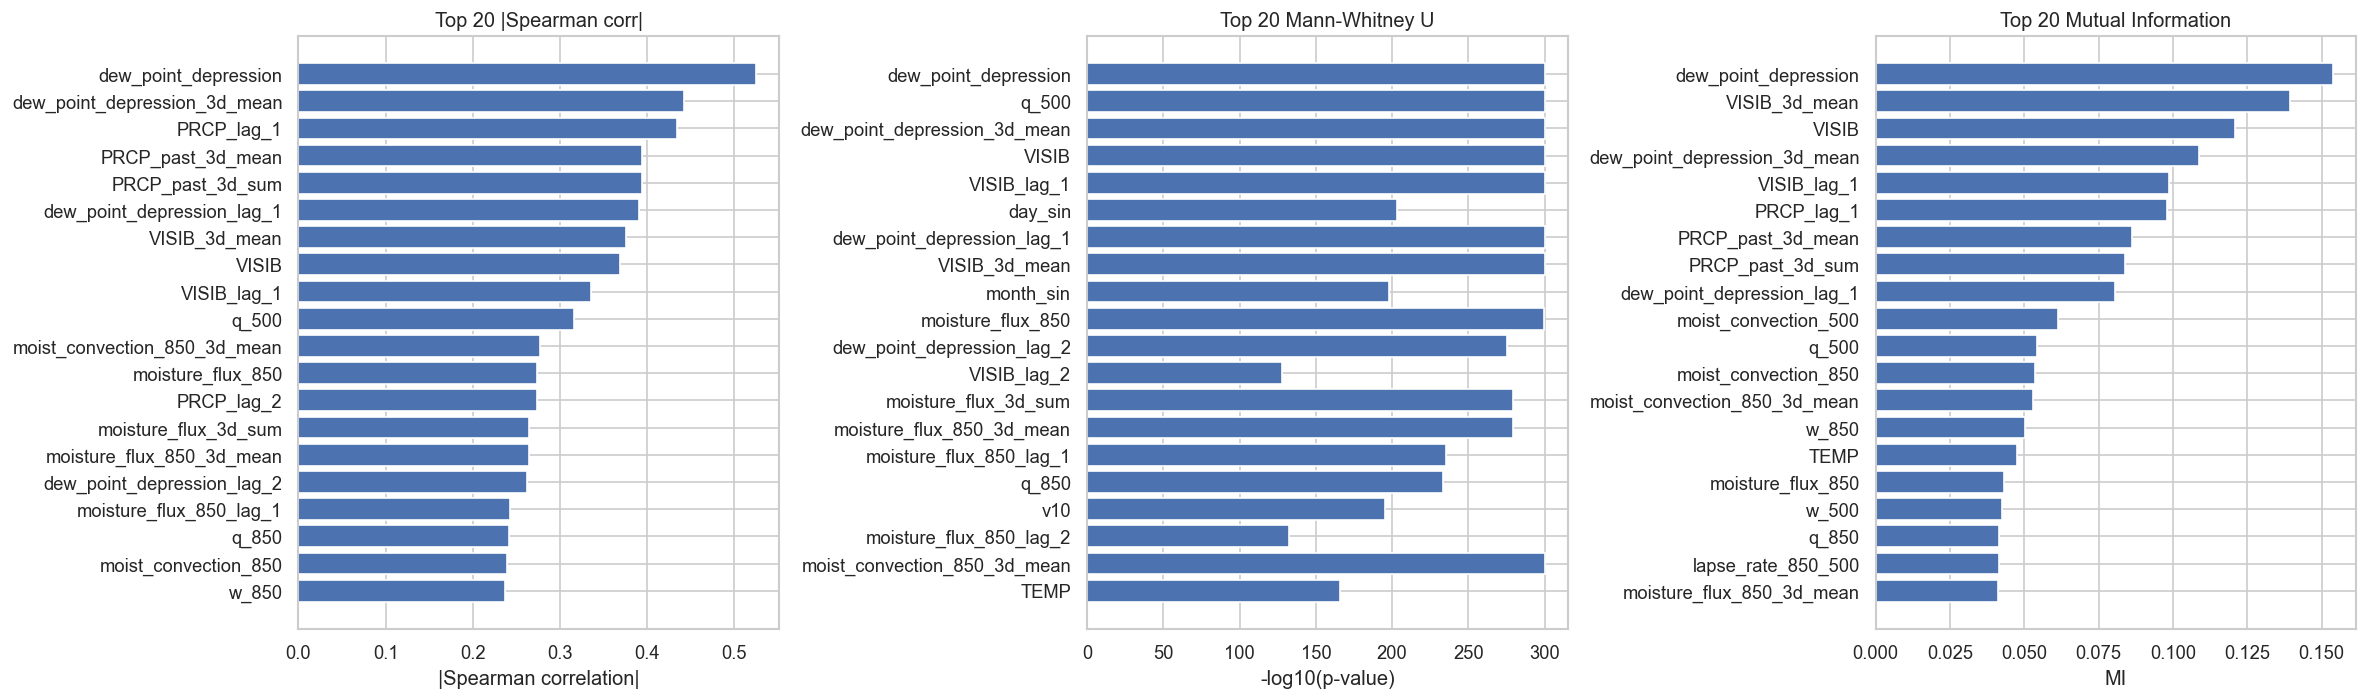

**Insight chung:**  \n- Feature xuất hiện mạnh ở nhiều tiêu chí thường đáng tin cậy hơn feature chỉ mạnh ở một tiêu chí.  \n- Các feature xuất hiện đồng thời trong top 20 của correlation, Mann-Whitney U và MI là: `['VISIB', 'VISIB_3d_mean', 'VISIB_lag_1', 'dew_point_depression', 'dew_point_depression_3d_mean', 'dew_point_depression_lag_1', 'moist_convection_850_3d_mean', 'moisture_flux_850', 'moisture_flux_850_3d_mean', 'q_500', 'q_850']`  \n- Nhóm feature nên ưu tiên thường gồm: độ ẩm, điểm sương, visibility, vận chuyển ẩm, mưa quá khứ và mùa vụ.

In [12]:
# 7.1 Correlation với target
corr_rows = []

for col in FEATURE_COLS:
    s = safe_numeric(df[col])
    y = safe_numeric(df[TARGET_COL])

    valid = s.notna() & y.notna()
    if valid.sum() < 20:
        continue

    pearson_corr = s[valid].corr(y[valid], method="pearson")
    spearman_corr = s[valid].corr(y[valid], method="spearman")

    corr_rows.append({
        "feature": col,
        "pearson_corr": pearson_corr,
        "spearman_corr": spearman_corr,
        "abs_spearman_corr": abs(spearman_corr),
    })

corr_df = (
    pd.DataFrame(corr_rows)
    .sort_values("abs_spearman_corr", ascending=False)
    .reset_index(drop=True)
)

# 7.2 Mann-Whitney U
mw_df = distribution_diff_df.copy()

# 7.3 Mutual Information
X_mi = df[FEATURE_COLS].apply(pd.to_numeric, errors="coerce")
y_mi = safe_numeric(df[TARGET_COL]).astype(int)

imputer = SimpleImputer(strategy="median")
X_mi_imp = imputer.fit_transform(X_mi)

mi_values = mutual_info_classif(
    X_mi_imp,
    y_mi,
    random_state=108,
    discrete_features=False,
)

mi_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "mutual_information": mi_values,
}).sort_values("mutual_information", ascending=False).reset_index(drop=True)

display(Markdown("### Top feature theo Spearman correlation"))
display(corr_df.head(20))

display(Markdown("### Top feature theo Mann-Whitney U"))
display(mw_df[["feature", "median_no_rain", "median_rain", "median_diff", "p_value", "minus_log10_p"]].head(20))

display(Markdown("### Top feature theo Mutual Information"))
display(mi_df.head(20))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

top_corr = corr_df.head(20).iloc[::-1]
axes[0].barh(top_corr["feature"], top_corr["abs_spearman_corr"])
axes[0].set_title("Top 20 |Spearman corr|")
axes[0].set_xlabel("|Spearman correlation|")

top_mw = mw_df.head(20).iloc[::-1]
axes[1].barh(top_mw["feature"], top_mw["minus_log10_p"])
axes[1].set_title("Top 20 Mann-Whitney U")
axes[1].set_xlabel("-log10(p-value)")

top_mi = mi_df.head(20).iloc[::-1]
axes[2].barh(top_mi["feature"], top_mi["mutual_information"])
axes[2].set_title("Top 20 Mutual Information")
axes[2].set_xlabel("MI")

plt.tight_layout()
plt.show()

common_strong = (
    set(corr_df.head(20)["feature"])
    & set(mw_df.head(20)["feature"])
    & set(mi_df.head(20)["feature"])
)

display(Markdown(
    "**Insight chung:**  \\n"
    "- Feature xuất hiện mạnh ở nhiều tiêu chí thường đáng tin cậy hơn feature chỉ mạnh ở một tiêu chí.  \\n"
    f"- Các feature xuất hiện đồng thời trong top 20 của correlation, Mann-Whitney U và MI là: `{sorted(common_strong)}`  \\n"
    "- Nhóm feature nên ưu tiên thường gồm: độ ẩm, điểm sương, visibility, vận chuyển ẩm, mưa quá khứ và mùa vụ."
))


## 8. Heatmap tương quan toàn bộ biến và xử lý đa cộng tuyến


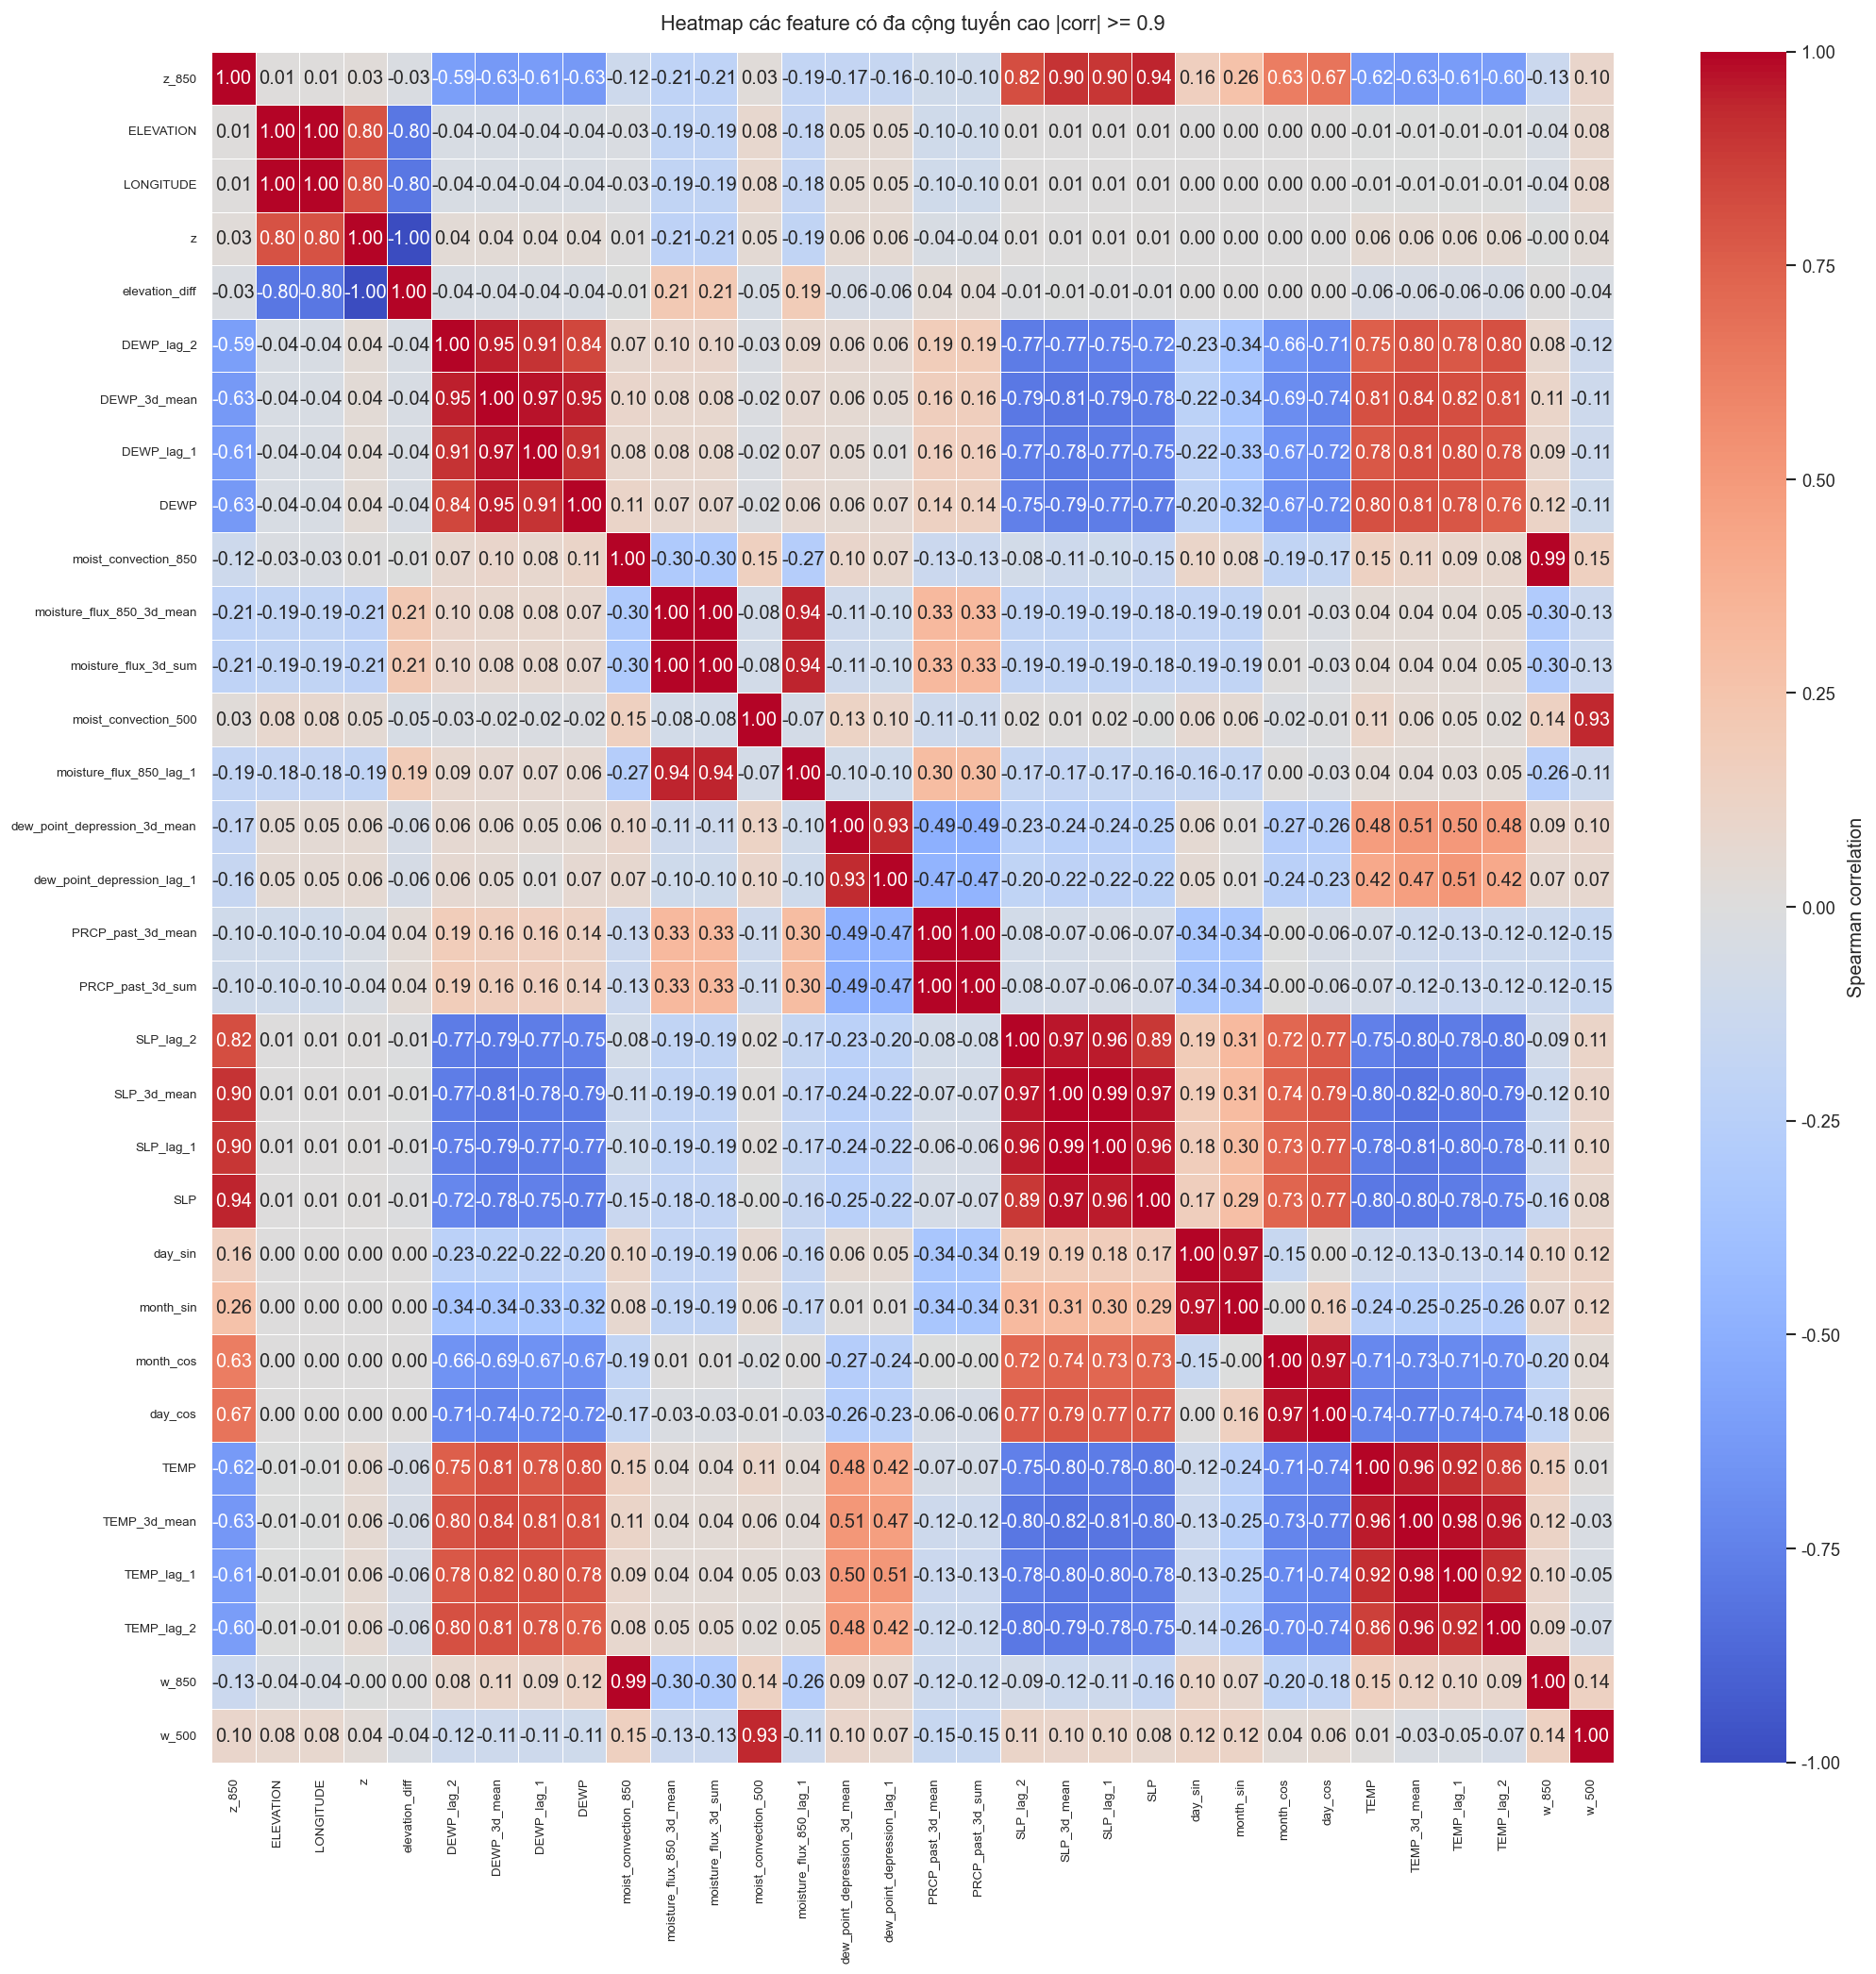

### Các cặp feature có đa cộng tuyến cao

,feature_1,feature_2,spearman_corr,feature_1_group,feature_2_group,suggest_keep,suggest_review_or_drop,reason
0,LONGITUDE,ELEVATION,1.000000,geography,geography,ELEVATION,LONGITUDE,Giữ feature có mức liên quan với rain_target c...
1,z,elevation_diff,-1.000000,geography,geography,elevation_diff,z,Ưu tiên feature engineered vì có ý nghĩa khí t...
2,moisture_flux_850_3d_mean,moisture_flux_3d_sum,1.000000,moisture_dynamic,moisture_dynamic,moisture_flux_850_3d_mean,moisture_flux_3d_sum,Rolling mean và rolling sum gần trùng thông ti...
3,PRCP_past_3d_mean,PRCP_past_3d_sum,1.000000,precipitation_history,precipitation_history,PRCP_past_3d_mean,PRCP_past_3d_sum,Rolling mean và rolling sum gần trùng thông ti...
4,SLP_lag_1,SLP_3d_mean,0.993523,pressure,pressure,SLP_3d_mean,SLP_lag_1,Giữ feature có mức liên quan với rain_target c...
5,w_850,moist_convection_850,0.993027,wind_dynamic,moisture_dynamic,moist_convection_850,w_850,Ưu tiên feature engineered vì có ý nghĩa khí t...
6,TEMP_lag_1,TEMP_3d_mean,0.979744,thermodynamic,thermodynamic,TEMP_3d_mean,TEMP_lag_1,Giữ feature có mức liên quan với rain_target c...
7,DEWP_lag_1,DEWP_3d_mean,0.974748,moisture,moisture,DEWP_3d_mean,DEWP_lag_1,Giữ feature có mức liên quan với rain_target c...
8,day_sin,month_sin,0.970171,seasonality,seasonality,day_sin,month_sin,Giữ feature có mức liên quan với rain_target c...
9,day_cos,month_cos,0.970152,seasonality,seasonality,month_cos,day_cos,Giữ feature có mức liên quan với rain_target c...


### Danh sách feature nên review do đa cộng tuyến

,feature_to_review,n_high_corr_pairs,max_abs_corr,kept_against,reason
5,SLP,3,0.970051,"SLP_3d_mean, SLP_lag_1, z_850",Giữ feature có mức liên quan với rain_target c...
7,SLP_lag_1,2,0.993523,"SLP_3d_mean, SLP_lag_2",Giữ feature có mức liên quan với rain_target c...
9,TEMP_lag_1,2,0.979744,"TEMP, TEMP_3d_mean",Giữ feature có mức liên quan với rain_target c...
2,DEWP_lag_1,2,0.974748,"DEWP_3d_mean, DEWP_lag_2",Giữ feature có mức liên quan với rain_target c...
6,SLP_3d_mean,2,0.968291,"SLP_lag_2, z_850",Giữ feature có mức liên quan với rain_target c...
10,TEMP_lag_2,2,0.957123,"TEMP_3d_mean, TEMP_lag_1",Giữ feature có mức liên quan với rain_target c...
0,DEWP,2,0.951701,"DEWP_3d_mean, DEWP_lag_1",Giữ feature có mức liên quan với rain_target c...
14,moisture_flux_850_lag_1,2,0.943701,"moisture_flux_3d_sum, moisture_flux_850_3d_mean",Giữ feature có mức liên quan với rain_target c...
3,LONGITUDE,1,1.000000,ELEVATION,Giữ feature có mức liên quan với rain_target c...
13,moisture_flux_3d_sum,1,1.000000,moisture_flux_850_3d_mean,Rolling mean và rolling sum gần trùng thông ti...



**Insight đa cộng tuyến và gợi ý lọc feature:**

- Heatmap trên chỉ giữ lại các feature thuộc các cặp có `|corr| >= 0.9`, nên phục vụ trực tiếp cho **feature selection**, không còn quá rối như heatmap full biến.
- Có **28 cặp feature** bị đa cộng tuyến cao và **19 feature** được đưa vào diện **review** nếu muốn rút gọn mô hình.

**Những nhóm trùng thông tin nổi bật:**
- **Seasonality:** các cặp như `day_sin - month_sin`, `day_cos - month_cos` có tương quan rất cao.  
  → Thường chỉ cần giữ bộ seasonal gọn, tránh để nhiều biến chu kỳ gần như trùng nhau.
- **Pressure:** `SLP`, `SLP_lag_1`, `SLP_lag_2`, `SLP_3d_mean` trùng thông tin mạnh.  
  → Ưu tiên giữ biến nào có tín hiệu với target tốt hơn; thường `SLP` hoặc `SLP_3d_mean` là đủ.
- **Thermodynamic:** `TEMP`, `TEMP_lag_1`, `TEMP_lag_2`, `TEMP_3d_mean` cũng trùng thông tin cao.  
  → Có thể giữ biến hiện tại + một biến rolling/lags tiêu biểu, không cần giữ toàn bộ.
- **Moisture:** `DEWP`, `DEWP_lag_1`, `DEWP_lag_2`, `DEWP_3d_mean` rất gần nhau.  
  → Thường chỉ cần giữ 1–2 biến đại diện.
- **Geography:** `LONGITUDE`, `ELEVATION`, `z`, `elevation_diff` có một số cặp rất cao.  
  → Không nên giữ toàn bộ nếu chúng phản ánh gần như cùng một thông tin không gian/địa hình.
- **Moisture dynamic:** `moisture_flux_850_3d_mean` và `moisture_flux_3d_sum` gần như trùng nhau.  
  → Ưu tiên giữ `mean` vì dễ diễn giải hơn.

**Nguyên tắc lọc feature nên áp dụng:**
1. Không xóa chỉ vì corr cao; phải xem thêm **ý nghĩa khí tượng** và **tín hiệu với target**.
2. Nếu hai feature trùng nhau mạnh, ưu tiên giữ:
   - feature có **Mutual Information / target relevance cao hơn**, hoặc
   - feature **engineered** có ý nghĩa khí tượng rõ hơn.
3. Với mô hình cây như LightGBM/Random Forest, đa cộng tuyến không quá nguy hiểm như Logistic Regression, nhưng vẫn nên review để:
   - báo cáo chặt hơn,
   - mô hình gọn hơn,
   - feature importance dễ giải thích hơn.

**Kết luận thực hành:**
- Nhóm nên cân nhắc **giảm bớt trước tiên** thường là:
  - các biến `SLP_*`
  - các biến `TEMP_*`
  - các biến `DEWP_*`
  - các cặp rolling `mean/sum`
  - một phần biến geography trùng nhau.
- Không nhất thiết drop ngay trong notebook này; nên đưa chúng vào nhóm **REVIEW / DROP_CANDIDATE** ở bước feature selection cuối.


In [13]:
# ============================================================
# HEATMAP ĐA CỘNG TUYẾN + GỢI Ý CHỌN LỌC FEATURE
# Chỉ vẽ heatmap cho các feature có |corr| >= threshold
# ============================================================

from IPython.display import display, Markdown
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Chuẩn bị dữ liệu numeric
# ------------------------------------------------------------
threshold_corr = 0.90

X_corr = df[FEATURE_COLS].apply(pd.to_numeric, errors="coerce")

# Loại feature toàn NaN hoặc hằng số
valid_features = [
    col for col in X_corr.columns
    if X_corr[col].notna().sum() > 0 and X_corr[col].nunique(dropna=True) > 1
]

X_corr = X_corr[valid_features].astype(float)
corr_matrix = X_corr.corr(method="spearman").astype(float)

# ------------------------------------------------------------
# 2. Tính tín hiệu liên quan với target để hỗ trợ chọn feature
# ------------------------------------------------------------
# Nếu corr_df / mi_df đã có từ cell trước thì sẽ dùng lại.
# Nếu chưa có thì tự tính trong cell này.

if "corr_df" not in globals():
    corr_rows = []
    for col in valid_features:
        s = pd.to_numeric(df[col], errors="coerce")
        y = pd.to_numeric(df[TARGET_COL], errors="coerce")
        valid = s.notna() & y.notna()

        if valid.sum() < 20:
            continue

        sp_corr = s[valid].corr(y[valid], method="spearman")
        corr_rows.append({
            "feature": col,
            "spearman_corr_target": sp_corr,
            "abs_spearman_corr_target": abs(sp_corr)
        })

    corr_df_local = pd.DataFrame(corr_rows)
else:
    corr_df_local = corr_df.copy()

    # Chuẩn hóa tên cột nếu notebook cũ đặt khác
    if "abs_spearman_corr_target" not in corr_df_local.columns:
        if "abs_spearman_corr" in corr_df_local.columns:
            corr_df_local["abs_spearman_corr_target"] = corr_df_local["abs_spearman_corr"]
        elif "spearman_corr" in corr_df_local.columns:
            corr_df_local["abs_spearman_corr_target"] = corr_df_local["spearman_corr"].abs()

if "mi_df" not in globals():
    X_mi = df[valid_features].apply(pd.to_numeric, errors="coerce")
    y_mi = pd.to_numeric(df[TARGET_COL], errors="coerce").astype(int)

    imputer = SimpleImputer(strategy="median")
    X_mi_imp = imputer.fit_transform(X_mi)

    mi_values = mutual_info_classif(
        X_mi_imp,
        y_mi,
        random_state=108,
        discrete_features=False
    )

    mi_df_local = pd.DataFrame({
        "feature": valid_features,
        "mutual_information": mi_values
    })
else:
    mi_df_local = mi_df.copy()

# Gộp signal theo target
feature_signal = pd.DataFrame({"feature": valid_features})

feature_signal = feature_signal.merge(
    corr_df_local[["feature", "abs_spearman_corr_target"]],
    on="feature",
    how="left"
)

feature_signal = feature_signal.merge(
    mi_df_local[["feature", "mutual_information"]],
    on="feature",
    how="left"
)

feature_signal["abs_spearman_corr_target"] = feature_signal["abs_spearman_corr_target"].fillna(0)
feature_signal["mutual_information"] = feature_signal["mutual_information"].fillna(0)

def minmax_scale(series):
    s = pd.to_numeric(series, errors="coerce").fillna(0)
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

feature_signal["corr_score_norm"] = minmax_scale(feature_signal["abs_spearman_corr_target"])
feature_signal["mi_score_norm"] = minmax_scale(feature_signal["mutual_information"])

# Điểm tổng hợp để quyết định feature nào "đáng giữ" hơn
feature_signal["target_relevance_score"] = (
    0.5 * feature_signal["corr_score_norm"] +
    0.5 * feature_signal["mi_score_norm"]
)

# ------------------------------------------------------------
# 3. Gán nhóm feature để dễ diễn giải
# ------------------------------------------------------------
def feature_group_local(feature):
    f = feature.lower()

    if feature in {"day_sin", "day_cos", "month_sin", "month_cos"}:
        return "seasonality"

    if feature in {"DEWP", "dew_point_depression", "q_850", "q_500"} or "dewp" in f or "humidity" in f:
        return "moisture"

    if feature in {"TEMP", "t_850", "t_500"} or "temp" in f or "lapse_rate" in f or "thickness" in f:
        return "thermodynamic"

    if feature in {"SLP", "STP", "sp", "msl"} or "slp" in f or "pressure" in f:
        return "pressure"

    if feature in {"ENSO", "ENSO_lag_1", "ENSO_lag_2"} or "enso" in f:
        return "climate"

    if feature in {"LATITUDE", "LONGITUDE", "ELEVATION", "z", "z_850", "z_500", "elevation_diff", "lsm"}:
        return "geography"

    if "wind" in f or feature.startswith(("u_", "v_", "w_")) or "shear" in f or "ageostrophic" in f:
        return "wind_dynamic"

    if "moisture_flux" in f or "moist_convection" in f:
        return "moisture_dynamic"

    if "prcp" in f:
        return "precipitation_history"

    return "other"

feature_signal["feature_group"] = feature_signal["feature"].map(feature_group_local)

# ------------------------------------------------------------
# 4. Tìm các cặp đa cộng tuyến cao
# ------------------------------------------------------------
high_corr_pairs = []

cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        corr_val = corr_matrix.iloc[i, j]
        if pd.notna(corr_val) and abs(corr_val) >= threshold_corr:
            high_corr_pairs.append({
                "feature_1": cols[i],
                "feature_2": cols[j],
                "spearman_corr": corr_val,
                "abs_spearman_corr": abs(corr_val)
            })

if len(high_corr_pairs) == 0:
    display(Markdown(
        f"**Kết luận:** Không có cặp feature nào có `|Spearman correlation| >= {threshold_corr}`."
    ))
else:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
        "abs_spearman_corr", ascending=False
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # 5. Chỉ lấy các feature thuộc nhóm đa cộng tuyến cao để vẽ heatmap
    # --------------------------------------------------------
    high_corr_features = sorted(
        set(high_corr_df["feature_1"]).union(set(high_corr_df["feature_2"]))
    )

    # Sắp xếp feature cho heatmap: theo nhóm rồi theo điểm liên quan với target
    ordered_features = (
        feature_signal[feature_signal["feature"].isin(high_corr_features)]
        .sort_values(["feature_group", "target_relevance_score"], ascending=[True, False])
        ["feature"]
        .tolist()
    )

    corr_high = corr_matrix.loc[ordered_features, ordered_features]

    # --------------------------------------------------------
    # 6. Vẽ DUY NHẤT 1 heatmap như bạn yêu cầu
    # --------------------------------------------------------
    plt.figure(
        figsize=(
            max(11, 0.55 * len(ordered_features)),
            max(9, 0.55 * len(ordered_features))
        )
    )

    if HAS_SEABORN:
        sns.heatmap(
            corr_high,
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            annot=True,
            fmt=".2f",
            linewidths=0.3,
            cbar_kws={"label": "Spearman correlation"},
        )
    else:
        plt.imshow(
            corr_high.values.astype(float),
            aspect="auto",
            cmap="coolwarm",
            vmin=-1,
            vmax=1
        )
        plt.colorbar(label="Spearman correlation")
        plt.xticks(range(len(corr_high.columns)), corr_high.columns, rotation=90)
        plt.yticks(range(len(corr_high.index)), corr_high.index)

    plt.title(
        f"Heatmap các feature có đa cộng tuyến cao |corr| >= {threshold_corr}",
        fontsize=13,
        pad=14
    )
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 7. Gợi ý giữ / review feature trong từng cặp
    # --------------------------------------------------------
    engineered_keywords = [
        "dew_point_depression",
        "moisture_flux",
        "moist_convection",
        "lapse_rate",
        "wind_shear",
        "ageostrophic",
        "thickness",
        "elevation_diff",
    ]

    def is_engineered_feature(feature):
        f = feature.lower()
        return any(k in f for k in engineered_keywords)

    def get_feature_signal(feature_name):
        row = feature_signal.loc[feature_signal["feature"] == feature_name].iloc[0]
        return {
            "group": row["feature_group"],
            "target_score": row["target_relevance_score"],
            "mi": row["mutual_information"],
            "target_corr": row["abs_spearman_corr_target"],
        }

    def suggest_keep_drop(row):
        f1 = row["feature_1"]
        f2 = row["feature_2"]

        s1 = get_feature_signal(f1)
        s2 = get_feature_signal(f2)

        f1_engineered = is_engineered_feature(f1)
        f2_engineered = is_engineered_feature(f2)

        pair_text = f"{f1} {f2}".lower()

        # 1) rolling mean vs rolling sum
        if "mean" in pair_text and "sum" in pair_text:
            if "mean" in f1.lower():
                return pd.Series({
                    "suggest_keep": f1,
                    "suggest_review_or_drop": f2,
                    "reason": "Rolling mean và rolling sum gần trùng thông tin; ưu tiên giữ mean để dễ diễn giải."
                })
            else:
                return pd.Series({
                    "suggest_keep": f2,
                    "suggest_review_or_drop": f1,
                    "reason": "Rolling mean và rolling sum gần trùng thông tin; ưu tiên giữ mean để dễ diễn giải."
                })

        # 2) ưu tiên feature engineered nếu signal không kém nhiều
        if f1_engineered and (not f2_engineered) and s1["target_score"] >= 0.8 * s2["target_score"]:
            return pd.Series({
                "suggest_keep": f1,
                "suggest_review_or_drop": f2,
                "reason": "Ưu tiên feature engineered vì có ý nghĩa khí tượng rõ hơn và tín hiệu với target không kém nhiều."
            })

        if f2_engineered and (not f1_engineered) and s2["target_score"] >= 0.8 * s1["target_score"]:
            return pd.Series({
                "suggest_keep": f2,
                "suggest_review_or_drop": f1,
                "reason": "Ưu tiên feature engineered vì có ý nghĩa khí tượng rõ hơn và tín hiệu với target không kém nhiều."
            })

        # 3) nếu không, giữ feature có target relevance cao hơn
        if s1["target_score"] >= s2["target_score"]:
            return pd.Series({
                "suggest_keep": f1,
                "suggest_review_or_drop": f2,
                "reason": "Giữ feature có mức liên quan với rain_target cao hơn."
            })
        else:
            return pd.Series({
                "suggest_keep": f2,
                "suggest_review_or_drop": f1,
                "reason": "Giữ feature có mức liên quan với rain_target cao hơn."
            })

    suggestion_df = high_corr_df.apply(suggest_keep_drop, axis=1)
    high_corr_df = pd.concat([high_corr_df, suggestion_df], axis=1)

    # Bổ sung thông tin nhóm feature
    high_corr_df["feature_1_group"] = high_corr_df["feature_1"].map(
        feature_signal.set_index("feature")["feature_group"].to_dict()
    )
    high_corr_df["feature_2_group"] = high_corr_df["feature_2"].map(
        feature_signal.set_index("feature")["feature_group"].to_dict()
    )

    high_corr_df["feature_1_target_score"] = high_corr_df["feature_1"].map(
        feature_signal.set_index("feature")["target_relevance_score"].to_dict()
    )
    high_corr_df["feature_2_target_score"] = high_corr_df["feature_2"].map(
        feature_signal.set_index("feature")["target_relevance_score"].to_dict()
    )

    display(Markdown("### Các cặp feature có đa cộng tuyến cao"))
    display(high_corr_df[[
        "feature_1",
        "feature_2",
        "spearman_corr",
        "feature_1_group",
        "feature_2_group",
        "suggest_keep",
        "suggest_review_or_drop",
        "reason"
    ]])

    # --------------------------------------------------------
    # 8. Tổng hợp feature nên review
    # --------------------------------------------------------
    review_summary = (
        high_corr_df
        .groupby("suggest_review_or_drop")
        .agg(
            n_high_corr_pairs=("suggest_review_or_drop", "count"),
            max_abs_corr=("abs_spearman_corr", "max"),
            kept_against=("suggest_keep", lambda x: ", ".join(sorted(set(x)))),
            reason=("reason", lambda x: "; ".join(sorted(set(x))))
        )
        .reset_index()
        .rename(columns={"suggest_review_or_drop": "feature_to_review"})
        .sort_values(["n_high_corr_pairs", "max_abs_corr"], ascending=[False, False])
    )

    display(Markdown("### Danh sách feature nên review do đa cộng tuyến"))
    display(review_summary)

    # --------------------------------------------------------
    # 9. Insight cuối cùng
    # --------------------------------------------------------
    review_features = review_summary["feature_to_review"].tolist()

    # Tạo một vài nhóm dễ diễn giải
    likely_redundant_groups = {
        "seasonality": [],
        "climate": [],
        "geography": [],
        "pressure": [],
        "thermodynamic": [],
        "moisture": [],
        "other": []
    }

    for f in review_features:
        grp = feature_group_local(f)
        if grp in likely_redundant_groups:
            likely_redundant_groups[grp].append(f)
        else:
            likely_redundant_groups["other"].append(f)

    insight_text = f"""
**Insight đa cộng tuyến và gợi ý lọc feature:**

- Heatmap trên chỉ giữ lại các feature thuộc các cặp có `|corr| >= {threshold_corr}`, nên phục vụ trực tiếp cho **feature selection**, không còn quá rối như heatmap full biến.
- Có **{len(high_corr_df)} cặp feature** bị đa cộng tuyến cao và **{len(review_features)} feature** được đưa vào diện **review** nếu muốn rút gọn mô hình.

**Những nhóm trùng thông tin nổi bật:**
- **Seasonality:** các cặp như `day_sin - month_sin`, `day_cos - month_cos` có tương quan rất cao.  
  → Thường chỉ cần giữ bộ seasonal gọn, tránh để nhiều biến chu kỳ gần như trùng nhau.
- **Pressure:** `SLP`, `SLP_lag_1`, `SLP_lag_2`, `SLP_3d_mean` trùng thông tin mạnh.  
  → Ưu tiên giữ biến nào có tín hiệu với target tốt hơn; thường `SLP` hoặc `SLP_3d_mean` là đủ.
- **Thermodynamic:** `TEMP`, `TEMP_lag_1`, `TEMP_lag_2`, `TEMP_3d_mean` cũng trùng thông tin cao.  
  → Có thể giữ biến hiện tại + một biến rolling/lags tiêu biểu, không cần giữ toàn bộ.
- **Moisture:** `DEWP`, `DEWP_lag_1`, `DEWP_lag_2`, `DEWP_3d_mean` rất gần nhau.  
  → Thường chỉ cần giữ 1–2 biến đại diện.
- **Geography:** `LONGITUDE`, `ELEVATION`, `z`, `elevation_diff` có một số cặp rất cao.  
  → Không nên giữ toàn bộ nếu chúng phản ánh gần như cùng một thông tin không gian/địa hình.
- **Moisture dynamic:** `moisture_flux_850_3d_mean` và `moisture_flux_3d_sum` gần như trùng nhau.  
  → Ưu tiên giữ `mean` vì dễ diễn giải hơn.

**Nguyên tắc lọc feature nên áp dụng:**
1. Không xóa chỉ vì corr cao; phải xem thêm **ý nghĩa khí tượng** và **tín hiệu với target**.
2. Nếu hai feature trùng nhau mạnh, ưu tiên giữ:
   - feature có **Mutual Information / target relevance cao hơn**, hoặc
   - feature **engineered** có ý nghĩa khí tượng rõ hơn.
3. Với mô hình cây như LightGBM/Random Forest, đa cộng tuyến không quá nguy hiểm như Logistic Regression, nhưng vẫn nên review để:
   - báo cáo chặt hơn,
   - mô hình gọn hơn,
   - feature importance dễ giải thích hơn.

**Kết luận thực hành:**
- Nhóm nên cân nhắc **giảm bớt trước tiên** thường là:
  - các biến `SLP_*`
  - các biến `TEMP_*`
  - các biến `DEWP_*`
  - các cặp rolling `mean/sum`
  - một phần biến geography trùng nhau.
- Không nhất thiết drop ngay trong notebook này; nên đưa chúng vào nhóm **REVIEW / DROP_CANDIDATE** ở bước feature selection cuối.
"""
    display(Markdown(insight_text))

## 9. Chọn lọc ra những đặc trưng cuối cùng


## 9.1. Bảng chọn lọc đặc trưng cuối cùng

Phần này tổng hợp toàn bộ kết quả EDA ở trên thành bảng khuyến nghị feature theo đúng mục tiêu two-stage và tránh data leakage.

In [14]:
# ============================================================
# FINAL FEATURE SELECTION TABLE
# ============================================================

def feature_group_report(feature: str) -> str:
    f = feature.lower()
    if "prcp_past" in f or "lag" in f or "3d" in f:
        return "temporal_memory"
    if f in ["day_sin", "day_cos", "month_sin", "month_cos"] or "month" in f or "day" in f:
        return "seasonality"
    if any(k in f for k in ["q_", "dewp", "dew_point", "moisture", "visib"]):
        return "moisture"
    if any(k in f for k in ["temp", "t_", "lapse", "convection"]):
        return "thermodynamic"
    if any(k in f for k in ["u_", "v_", "wind", "shear", "ageostrophic", "du_", "dv_", "wdsp"]):
        return "wind_dynamic"
    if any(k in f for k in ["slp", "stp", "sp", "msl", "pressure"]):
        return "pressure"
    if any(k in f for k in ["lat", "lon", "elevation", "z", "thickness", "lsm"]):
        return "geography_vertical"
    return "other"


def meteorological_meaning(feature: str) -> str:
    f = feature.lower()
    if "prcp_past" in f:
        return "Lịch sử mưa gần đây, giúp mô hình học tính dai dẳng của mưa."
    if "moisture_flux" in f:
        return "Vận chuyển ẩm, liên quan trực tiếp đến nguồn hơi nước gây mưa."
    if "convection" in f:
        return "Tín hiệu đối lưu ẩm, phản ánh chuyển động thẳng đứng và độ ẩm."
    if "dew_point" in f or "dewp" in f:
        return "Độ ẩm/điểm sương, biến nền quan trọng cho hình thành mưa."
    if "visib" in f:
        return "Tầm nhìn, thường giảm trong điều kiện mưa hoặc ẩm cao."
    if "slp" in f or "stp" in f:
        return "Áp suất bề mặt, phản ánh trạng thái hệ thống thời tiết."
    if "wind" in f or "u_" in f or "v_" in f:
        return "Trường gió và động lực khí quyển."
    if "lapse" in f or "thickness" in f:
        return "Cấu trúc thẳng đứng và ổn định khí quyển."
    if "day" in f or "month" in f:
        return "Mùa vụ, chu kỳ khí hậu trong năm."
    return "Biến khí tượng/phụ trợ có thể hỗ trợ mô hình."


# 1) Tổng hợp điểm từ correlation, Mann-Whitney và Mutual Information
selection_df = pd.DataFrame({"feature": FEATURE_COLS})

if "corr_df" in globals() and not corr_df.empty:
    selection_df = selection_df.merge(
        corr_df[["feature", "abs_spearman_corr"]],
        on="feature",
        how="left",
    )
else:
    selection_df["abs_spearman_corr"] = np.nan

if "mi_df" in globals() and not mi_df.empty:
    selection_df = selection_df.merge(
        mi_df[["feature", "mutual_information"]],
        on="feature",
        how="left",
    )
else:
    selection_df["mutual_information"] = np.nan

if "distribution_diff_df" in globals() and not distribution_diff_df.empty:
    selection_df = selection_df.merge(
        distribution_diff_df[[
            "feature",
            "median_no_rain",
            "median_rain",
            "median_diff",
            "abs_standardized_median_diff",
            "p_value",
            "minus_log10_p",
        ]],
        on="feature",
        how="left",
    )
else:
    for col in ["median_no_rain", "median_rain", "median_diff", "abs_standardized_median_diff", "p_value", "minus_log10_p"]:
        selection_df[col] = np.nan

# 2) Đánh dấu redundancy từ heatmap đa cộng tuyến
review_features = set()
if "review_summary" in globals() and not review_summary.empty and "feature_to_review" in review_summary.columns:
    review_features = set(review_summary["feature_to_review"].dropna().astype(str))

selection_df["redundancy_note"] = np.where(
    selection_df["feature"].isin(review_features),
    "REVIEW: có tương quan cao với feature khác",
    "OK"
)

# 3) Tính điểm tổng hợp chỉ để xếp hạng EDA, không dùng để tune model trực tiếp
def minmax(series):
    series = pd.to_numeric(series, errors="coerce").fillna(0)
    max_val = series.max()
    min_val = series.min()
    if max_val == min_val:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - min_val) / (max_val - min_val)

selection_df["score_corr"] = minmax(selection_df["abs_spearman_corr"])
selection_df["score_mi"] = minmax(selection_df["mutual_information"])
selection_df["score_dist"] = minmax(selection_df["abs_standardized_median_diff"])
selection_df["feature_score"] = (
    0.35 * selection_df["score_corr"]
    + 0.35 * selection_df["score_mi"]
    + 0.30 * selection_df["score_dist"]
)

q80 = selection_df["feature_score"].quantile(0.80)
q50 = selection_df["feature_score"].quantile(0.50)
q25 = selection_df["feature_score"].quantile(0.25)

def recommend(row):
    if row["feature"] in review_features and row["feature_score"] < q80:
        return "REVIEW_FOR_REDUNDANCY"
    if row["feature_score"] >= q80:
        return "KEEP_STRONG"
    if row["feature_score"] >= q50:
        return "KEEP"
    if row["feature_score"] >= q25:
        return "REVIEW"
    return "DROP_CANDIDATE"

selection_df["feature_group"] = selection_df["feature"].apply(feature_group_report)
selection_df["meteorological_meaning"] = selection_df["feature"].apply(meteorological_meaning)
selection_df["final_recommendation"] = selection_df.apply(recommend, axis=1)

selection_df = (
    selection_df
    .sort_values(["feature_score", "mutual_information", "abs_spearman_corr"], ascending=False)
    .reset_index(drop=True)
)
selection_df["rank"] = np.arange(1, len(selection_df) + 1)

final_columns = [
    "rank",
    "feature",
    "feature_group",
    "abs_spearman_corr",
    "mutual_information",
    "abs_standardized_median_diff",
    "p_value",
    "minus_log10_p",
    "median_no_rain",
    "median_rain",
    "median_diff",
    "redundancy_note",
    "feature_score",
    "final_recommendation",
    "meteorological_meaning",
]

display(Markdown("### Bảng feature selection cuối cùng"))
display(selection_df[final_columns])

# 4) Danh sách feature theo nhóm khuyến nghị
feature_recommendation_summary = (
    selection_df
    .groupby("final_recommendation")
    .agg(
        n_features=("feature", "count"),
        features=("feature", lambda x: ", ".join(x.tolist())),
    )
    .reset_index()
)

display(Markdown("### Tổng hợp khuyến nghị"))
display(feature_recommendation_summary)

KEEP_STRONG = selection_df.loc[selection_df["final_recommendation"] == "KEEP_STRONG", "feature"].tolist()
KEEP = selection_df.loc[selection_df["final_recommendation"] == "KEEP", "feature"].tolist()
REVIEW = selection_df.loc[selection_df["final_recommendation"].isin(["REVIEW", "REVIEW_FOR_REDUNDANCY"]), "feature"].tolist()
DROP_CANDIDATE = selection_df.loc[selection_df["final_recommendation"] == "DROP_CANDIDATE", "feature"].tolist()

display(Markdown("### Feature lists dùng cho báo cáo"))
display(Markdown(f"**KEEP_STRONG ({len(KEEP_STRONG)}):** `{KEEP_STRONG}`"))
display(Markdown(f"**KEEP ({len(KEEP)}):** `{KEEP}`"))
display(Markdown(f"**REVIEW ({len(REVIEW)}):** `{REVIEW}`"))
display(Markdown(f"**DROP_CANDIDATE ({len(DROP_CANDIDATE)}):** `{DROP_CANDIDATE}`"))

display(Markdown(
    "**Kết luận Feature Selection:**  \n"
    "- Không đưa `PRCP`, `PRCP_label`, `PRCP_log1p`, `time`, `STATION` vào feature matrix khi train model.  \n"
    "- Các feature được `KEEP_STRONG` là nhóm vừa có tín hiệu thống kê, vừa dễ giải thích khí tượng.  \n"
    "- Các feature `REVIEW_FOR_REDUNDANCY` không nhất thiết xóa ngay, nhưng cần được giải thích vì có đa cộng tuyến cao.  \n"
    "- Với LightGBM, đa cộng tuyến không làm mô hình sai như linear model, nhưng lọc bớt giúp báo cáo và feature importance dễ bảo vệ hơn."
))


### Bảng feature selection cuối cùng

,rank,feature,feature_group,abs_spearman_corr,mutual_information,abs_standardized_median_diff,p_value,minus_log10_p,median_no_rain,median_rain,median_diff,redundancy_note,feature_score,final_recommendation,meteorological_meaning
0,1,dew_point_depression,moisture,0.525128,0.153903,1.171056,0.000000,300.000000,4.722200,2.833300,-1.888900,OK,1.000000,KEEP_STRONG,"Độ ẩm/điểm sương, biến nền quan trọng cho hình..."
1,2,dew_point_depression_3d_mean,temporal_memory,0.441850,0.108816,0.955771,0.000000,300.000000,4.574067,3.148133,-1.425933,OK,0.786554,KEEP_STRONG,"Độ ẩm/điểm sương, biến nền quan trọng cho hình..."
2,3,VISIB_3d_mean,temporal_memory,0.375705,0.139227,0.750200,0.000000,300.000000,19.580300,16.737167,-2.843133,OK,0.758762,KEEP_STRONG,"Tầm nhìn, thường giảm trong điều kiện mưa hoặc..."
3,4,VISIB,moisture,0.368369,0.120803,0.903592,0.000000,300.000000,19.955800,16.254300,-3.701500,OK,0.751247,KEEP_STRONG,"Tầm nhìn, thường giảm trong điều kiện mưa hoặc..."
4,5,VISIB_lag_1,temporal_memory,0.335965,0.098657,0.899030,0.000000,300.000000,19.955800,16.254300,-3.701500,OK,0.678018,KEEP_STRONG,"Tầm nhìn, thường giảm trong điều kiện mưa hoặc..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,66,LATITUDE,geography_vertical,0.021892,0.003190,0.000000,0.003098,2.508888,15.133300,15.133300,0.000000,OK,0.020305,DROP_CANDIDATE,Biến khí tượng/phụ trợ có thể hỗ trợ mô hình.
66,67,du_850_500,wind_dynamic,0.007046,0.005410,0.013766,0.341099,0.467120,-0.108200,-0.004100,0.104100,OK,0.018940,DROP_CANDIDATE,Trường gió và động lực khí quyển.
67,68,t_500,thermodynamic,0.012916,0.001434,0.033089,0.080986,1.091589,-4.334500,-4.380700,-0.046200,OK,0.018777,DROP_CANDIDATE,Biến khí tượng/phụ trợ có thể hỗ trợ mô hình.
68,69,u_500,wind_dynamic,0.026209,0.000000,0.005074,0.000399,3.399411,0.108500,0.068900,-0.039600,OK,0.017241,DROP_CANDIDATE,Trường gió và động lực khí quyển.


### Tổng hợp khuyến nghị

,final_recommendation,n_features,features
0,DROP_CANDIDATE,12,"lsm, v_500, ELEVATION, u_850_lag_1, u_850_lag_..."
1,KEEP,16,"dew_point_depression_lag_2, moist_convection_8..."
2,KEEP_STRONG,14,"dew_point_depression, dew_point_depression_3d_..."
3,REVIEW,12,"WDSP, dv_850_500, v_850_lag_1, u_850, SLP_lag_..."
4,REVIEW_FOR_REDUNDANCY,16,"month_sin, moisture_flux_850_lag_1, w_850, w_5..."


### Feature lists dùng cho báo cáo

**KEEP_STRONG (14):** `['dew_point_depression', 'dew_point_depression_3d_mean', 'VISIB_3d_mean', 'VISIB', 'VISIB_lag_1', 'dew_point_depression_lag_1', 'q_500', 'PRCP_lag_1', 'PRCP_past_3d_mean', 'PRCP_past_3d_sum', 'day_sin', 'moisture_flux_850', 'moisture_flux_3d_sum', 'moisture_flux_850_3d_mean']`

**KEEP (16):** `['dew_point_depression_lag_2', 'moist_convection_850_3d_mean', 'q_850', 'moist_convection_850', 'VISIB_lag_2', 'TEMP', 'v10', 'lapse_rate_850_500', 'moist_convection_500', 'moisture_flux_850_lag_2', 'PRCP_lag_2', 't_850', 'u10', 'z_500', 'ageostrophic_signal', 'DEWP_lag_2']`

**REVIEW (28):** `['month_sin', 'moisture_flux_850_lag_1', 'w_850', 'w_500', 'TEMP_3d_mean', 'DEWP_3d_mean', 'TEMP_lag_1', 'DEWP_lag_1', 'WDSP', 'dv_850_500', 'DEWP', 'v_850_lag_1', 'u_850', 'SLP_lag_2', 'z_850', 'thickness_500_850', 'wind_shear_mag', 'v_850', 'SLP_3d_mean', 'v_850_lag_2', 'STP', 'du_dt_850', 'SLP_lag_1', 'LONGITUDE', 'TEMP_lag_2', 'z', 'SLP', 'day_cos']`

**DROP_CANDIDATE (12):** `['lsm', 'v_500', 'ELEVATION', 'u_850_lag_1', 'u_850_lag_2', 'dv_dt_850', 'month_cos', 'elevation_diff', 'LATITUDE', 'du_850_500', 't_500', 'u_500']`

**Kết luận Feature Selection:**  
- Không đưa `PRCP`, `PRCP_label`, `PRCP_log1p`, `time`, `STATION` vào feature matrix khi train model.  
- Các feature được `KEEP_STRONG` là nhóm vừa có tín hiệu thống kê, vừa dễ giải thích khí tượng.  
- Các feature `REVIEW_FOR_REDUNDANCY` không nhất thiết xóa ngay, nhưng cần được giải thích vì có đa cộng tuyến cao.  
- Với LightGBM, đa cộng tuyến không làm mô hình sai như linear model, nhưng lọc bớt giúp báo cáo và feature importance dễ bảo vệ hơn.